#### Sources
[1][Anthropic Blog](https://www.anthropic.com/news/model-context-protocol) <br>
[2][Official Doc](https://modelcontextprotocol.io/docs/getting-started/intro) <br>
[3][Python SDK](https://github.com/modelcontextprotocol/python-sdk) <br>

# Introduction: Model Context Protocol (MCP) as an Architectural Primitive

Modern AI systems rarely operate in isolation. Production deployments of large language models require sustained, structured access to external data sources, APIs, enterprise tools, and runtime services. The engineering challenge is not whether to integrate these systems, but how to do so without creating a combinatorial maintenance burden that scales poorly and resists change. The Model Context Protocol (MCP), introduced by Anthropic as an open standard, directly addresses this structural problem by introducing a protocol-level abstraction between AI models and the services they consume.

This notebook examines MCP from a systems-architecture perspective: what problem it solves, how it restructures the integration topology, and why it matters for building extensible, maintainable AI infrastructure.


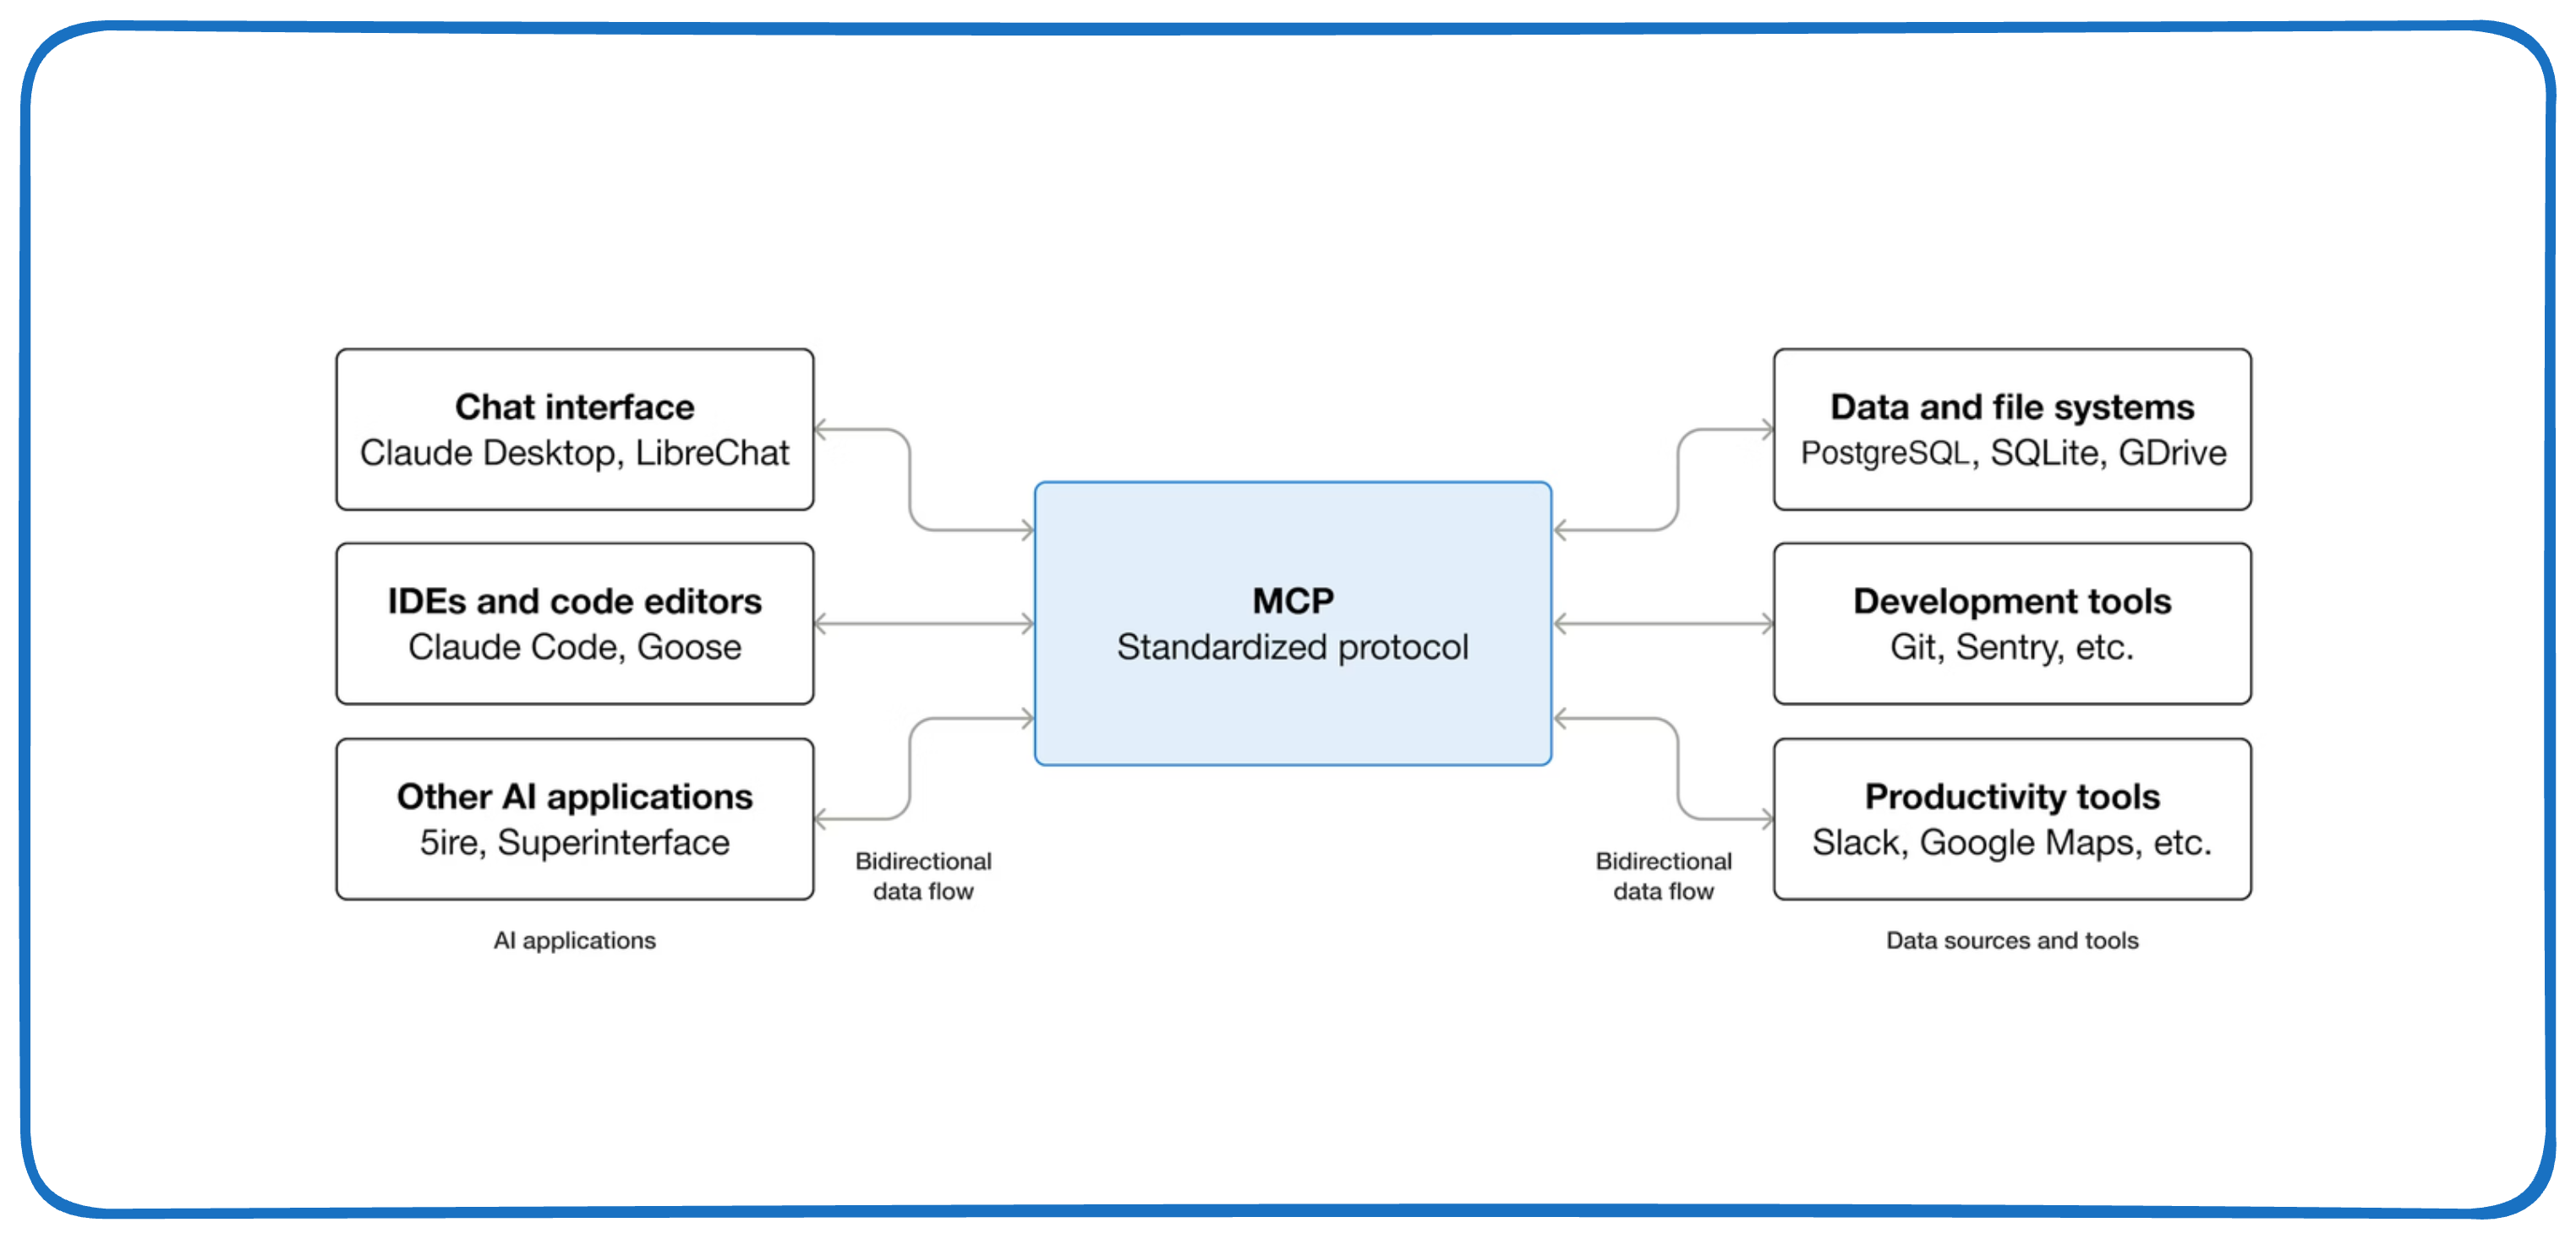


---

## 1. The Integration Scaling Problem in AI Systems

Consider a production environment where multiple AI models must interact with multiple external tools, data stores, and services. Each model may need access to a database, a file system, a search API, a code execution sandbox, a CRM, or any number of domain-specific backends. Without a shared integration standard, every connection between a model and a service requires a bespoke adapter: custom authentication logic, custom data serialization, custom error handling, and custom lifecycle management.

Let **M** denote the number of distinct AI models (or model-hosting applications) in an organization's stack, and **N** denote the number of external tools or services those models need to access. In the absence of a unifying protocol, each (model, service) pair demands its own dedicated connector. The result is a fully connected bipartite graph between models and services, yielding **M x N** distinct integration pathways, each independently developed, tested, versioned, and maintained.

This is not a hypothetical concern. As organizations adopt multiple frontier models from different providers (OpenAI, Anthropic, Google DeepMind, open-source alternatives) and simultaneously expand the surface area of tools available to those models, the integration matrix grows quadratically. Each new model added to the stack requires N new connectors. Each new service requires M new connectors. Operational complexity compounds: schema drift in a single API can cascade into M separate breakage events, one per model integration.

The direct-integration approach also produces architectural fragmentation. Different teams may implement semantically identical operations (e.g., "query a database" or "read a file") using incompatible patterns, data formats, and error semantics. This inconsistency makes it difficult to reason about system behavior, enforce security policies uniformly, or compose multi-step agent workflows reliably.

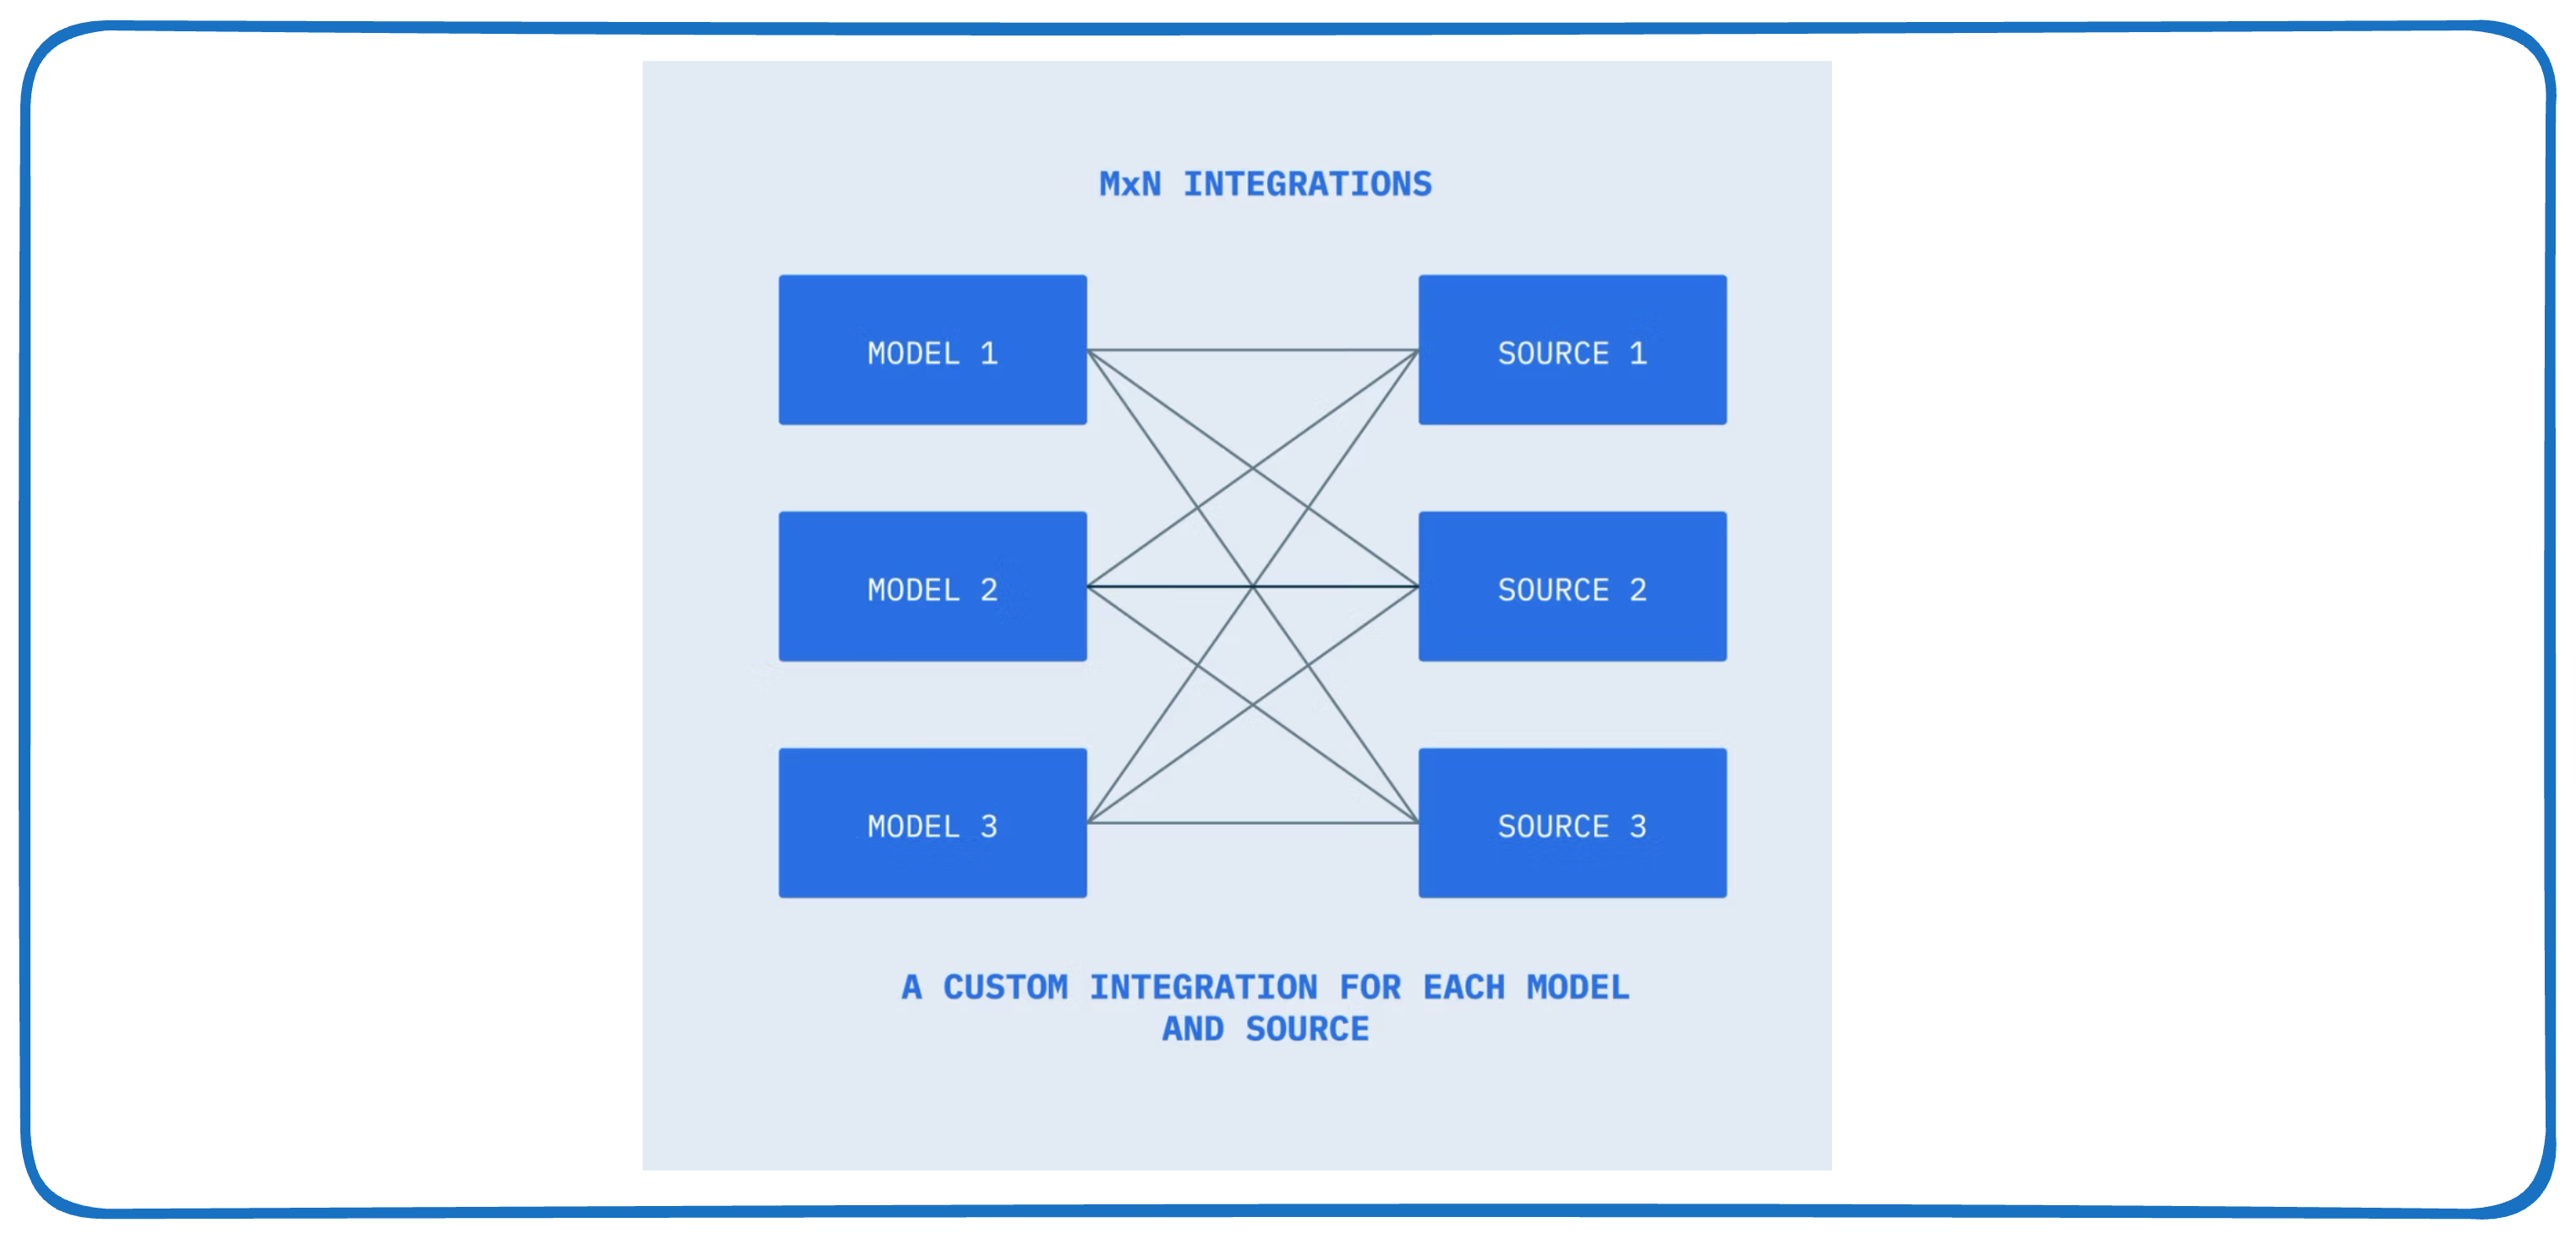

[]


---

## 2. The M x N Problem Explained Formally

To state the problem precisely:

- **M** = the cardinality of the set of AI model endpoints (or host applications) in a given deployment. Each element in M is an independent consumer of external capabilities.
- **N** = the cardinality of the set of external tools, data sources, or services. Each element in N exposes some capability (data retrieval, computation, side effects) that models may invoke.

Under direct integration, the total number of unique connectors required is the Cartesian product:

```
Total integrations = M x N
```

This is the **M x N problem**. Its implications are architectural, not merely quantitative:

- **Linear growth in either dimension produces multiplicative growth in integration effort.** Adding a single new model to a stack with 20 services requires 20 new connectors. Adding a single new service to a stack with 5 models requires 5 new connectors.
- **Maintenance burden scales with the product.** Each connector is an independent surface for bugs, security vulnerabilities, version incompatibilities, and behavioral inconsistencies. The total maintenance load is proportional to M x N, not to M or N individually.
- **Testing and validation become combinatorial.** Verifying correct behavior across all model-service pairs requires M x N test paths, each potentially exercising different code.
- **No reuse across the integration matrix.** A connector built for Model A to access Service X shares no interface contract, no serialization logic, and no authentication flow with a connector built for Model B to access the same Service X. The work is duplicated M times per service.

As AI ecosystems mature, both M and N are increasing simultaneously, driven by multi-model strategies on the model side and expanding tool ecosystems on the service side. The M x N growth rate renders direct integration fundamentally unscalable as an architectural strategy.

---

## 3. MCP and the M + N Model

The Model Context Protocol resolves the M x N problem through a classical systems-architecture technique: introducing a shared abstraction layer that decouples producers from consumers.

MCP defines a standardized interface, built on JSON-RPC 2.0, through which any model (acting as an MCP client) can discover, invoke, and receive results from any service (exposed via an MCP server). The protocol specifies how tools declare their capabilities, how requests are structured, how authentication is scoped, and how responses are returned. Crucially, this contract is model-agnostic and service-agnostic.

Under MCP, the integration topology changes from a fully connected bipartite graph to a hub-and-spoke architecture mediated by the protocol:

- Each of the **M** models implements the MCP client interface once. This single implementation grants it access to any MCP-compliant server.
- Each of the **N** services implements the MCP server interface once. This single implementation makes it accessible to any MCP-compliant client.

The total number of integration implementations reduces from **M x N** to:

```
Total integrations = M + N
```

This is a structural reduction in complexity, not merely an optimization. Adding a new model requires exactly one integration (the MCP client), regardless of how many services exist. Adding a new service requires exactly one integration (the MCP server), regardless of how many models exist. The system scales linearly, not quadratically.

The MCP server acts as an abstraction layer in front of each data source or tool. It receives structured requests from the client, translates them into safe, scoped operations against the underlying backend, and returns structured responses. The model never interacts with the backend directly. This decoupling provides several architectural guarantees: the backend's internal API can evolve independently of the models consuming it; security policies and access controls are enforced at the server boundary; and the model can introspect available capabilities dynamically via the protocol's discovery mechanisms.


---


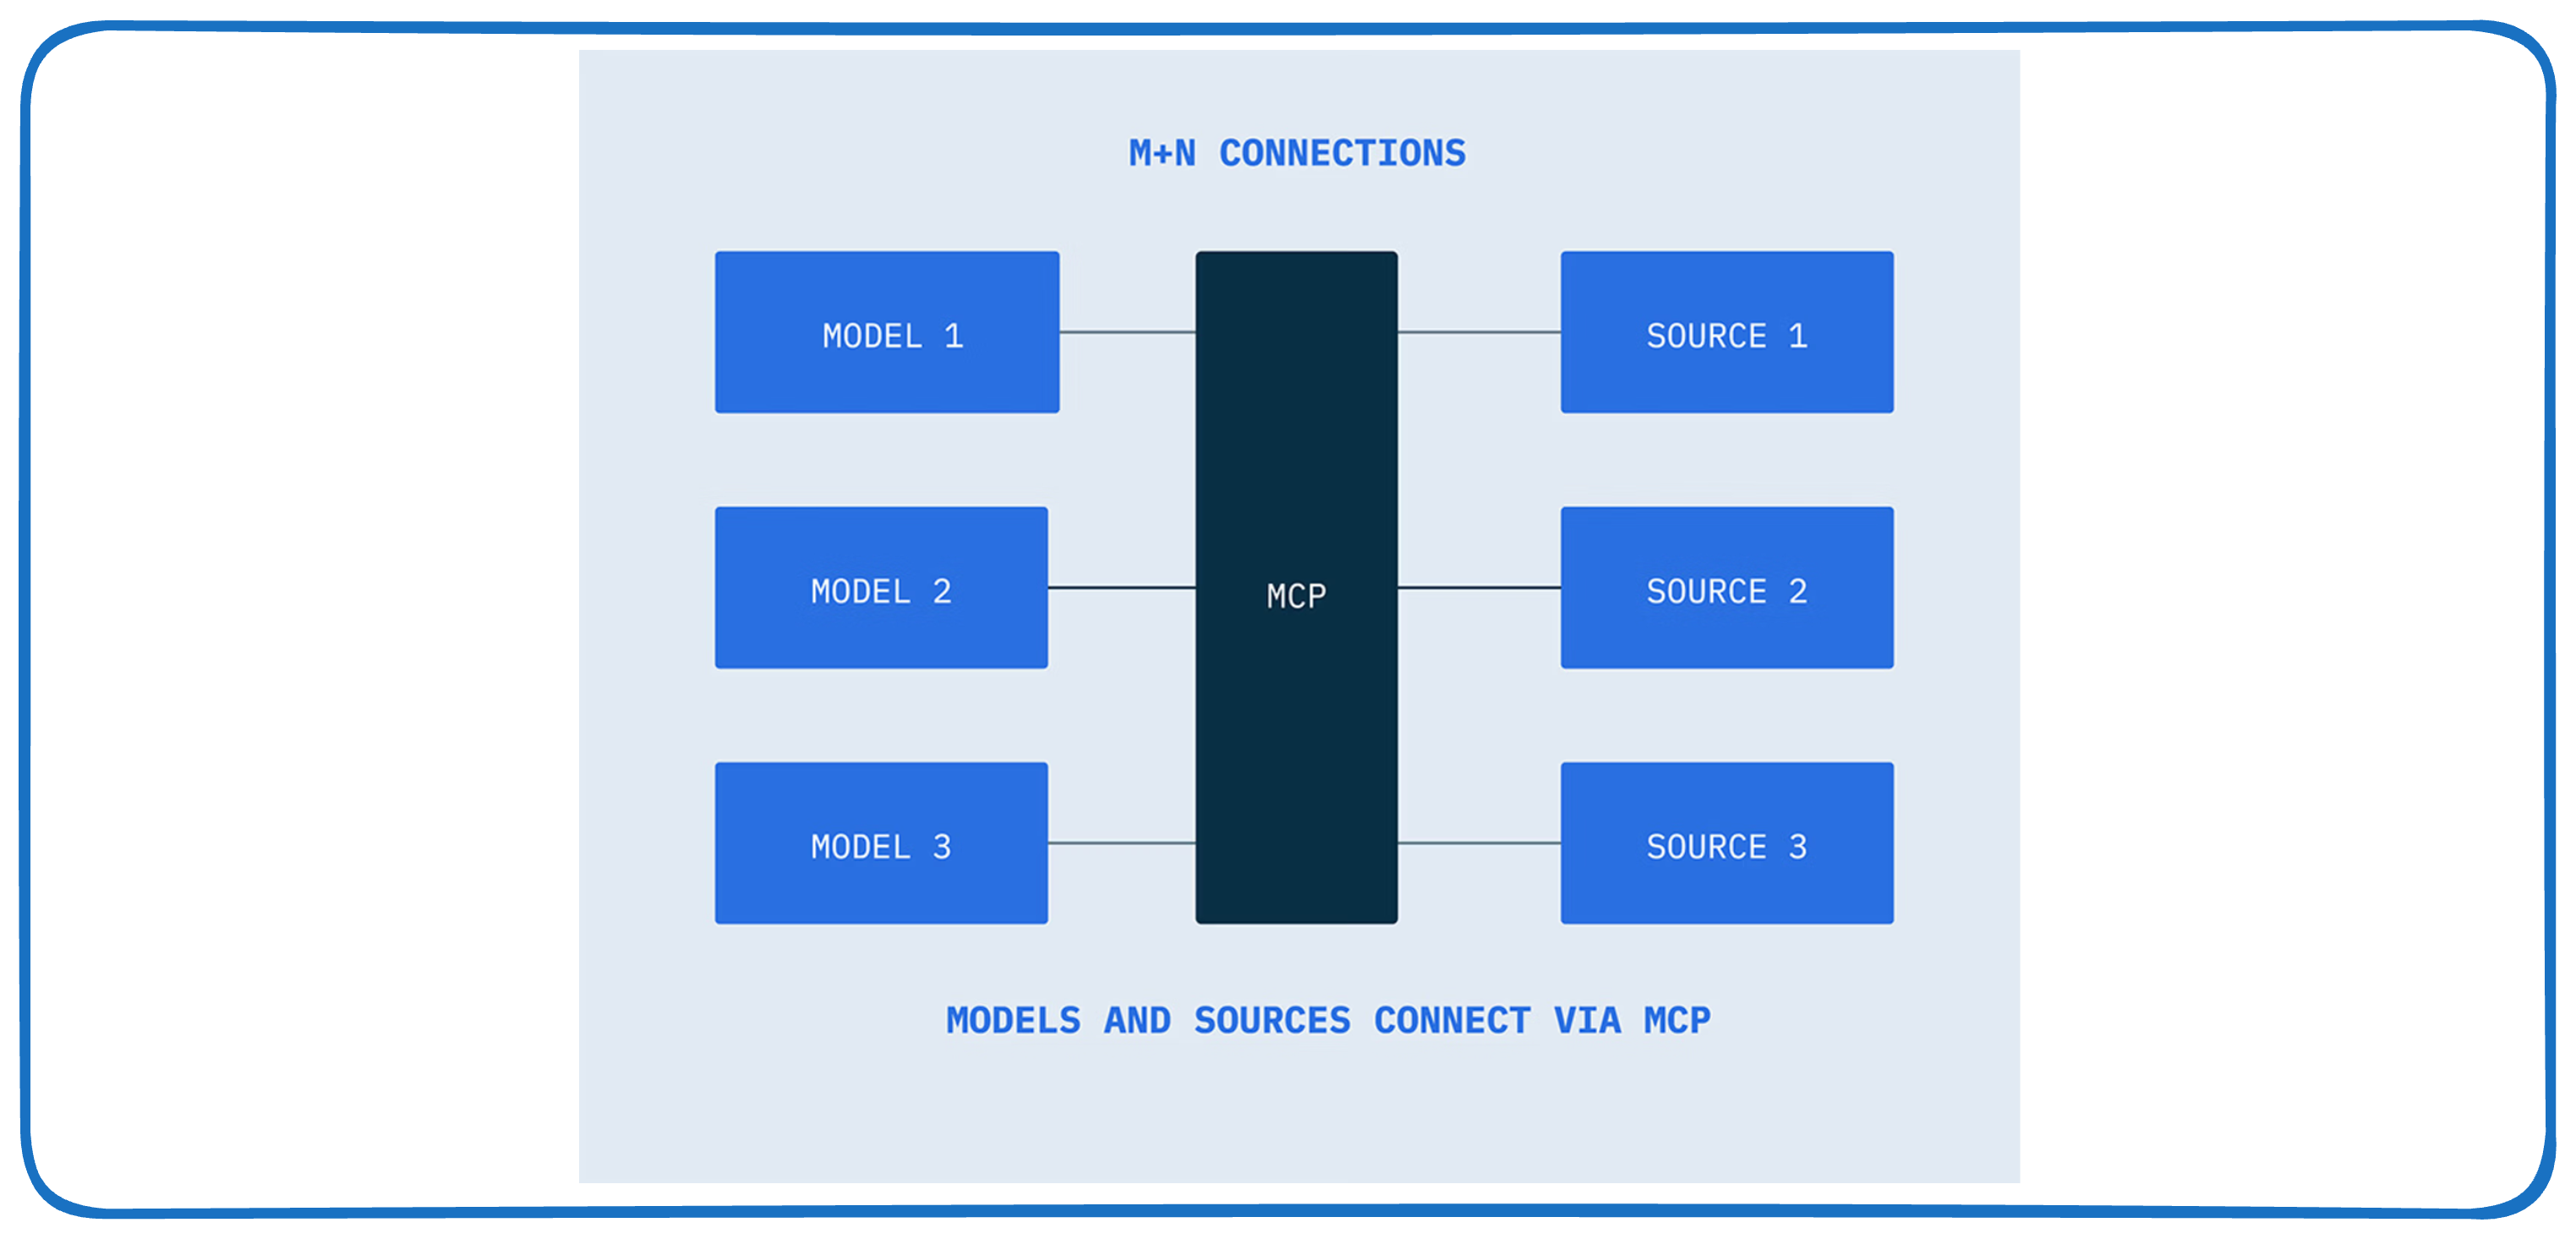

[Image Source](https://cloudsmith.com/blog/adding-ai-to-applications-using-mcp)


## 4. Why This Matters for Production AI Systems

The shift from M x N to M + N is not an incremental improvement. It is a change in the asymptotic scaling behavior of integration complexity, and it carries several consequences that are directly relevant to production AI architecture.

**Extensibility.** MCP-compliant systems are open to extension by default. New tools can be added to an agent's capability set by deploying a new MCP server, with zero modifications to the model or host application. This enables rapid iteration on tool ecosystems without destabilizing existing integrations, a property that is essential for organizations experimenting with agent architectures.

**Vendor neutrality.** Because MCP is an open standard with adoption across major providers, organizations are not locked into a single model vendor's tool-calling conventions. A tool exposed via MCP is accessible to any compliant client, whether it hosts a model from Anthropic, OpenAI, Google DeepMind, or an open-source alternative. This portability reduces switching costs and enables multi-model deployment strategies.

**Maintainability.** With M + N connectors instead of M x N, the total surface area for bugs, security vulnerabilities, and version drift is reduced by an order of magnitude in non-trivial deployments. Each connector has a single owner and a single interface contract. Schema changes in a backend service require updating one MCP server, not M separate adapters.

**Agent ecosystem composition.** Autonomous and semi-autonomous AI agents require the ability to discover, select, and invoke tools dynamically during multi-step workflows. MCP's capability discovery mechanism, where servers expose their available methods and the client can introspect them at runtime, provides the substrate for this. Agents can chain operations across multiple MCP servers in a single workflow without any of those servers being aware of each other, enabling composable, modular agent architectures.

**Long-term architectural leverage.** Protocols that standardize integration at the right level of abstraction tend to compound in value over time, much as HTTP standardized web communication and REST standardized API design. MCP occupies a similar position in the AI integration stack. Early adoption creates a foundation on which increasingly sophisticated agent capabilities, security models, and orchestration patterns can be built without rearchitecting the integration layer.

---

*The remainder of this notebook provides hands-on implementations of MCP clients and servers, demonstrating these architectural principles in working code.*

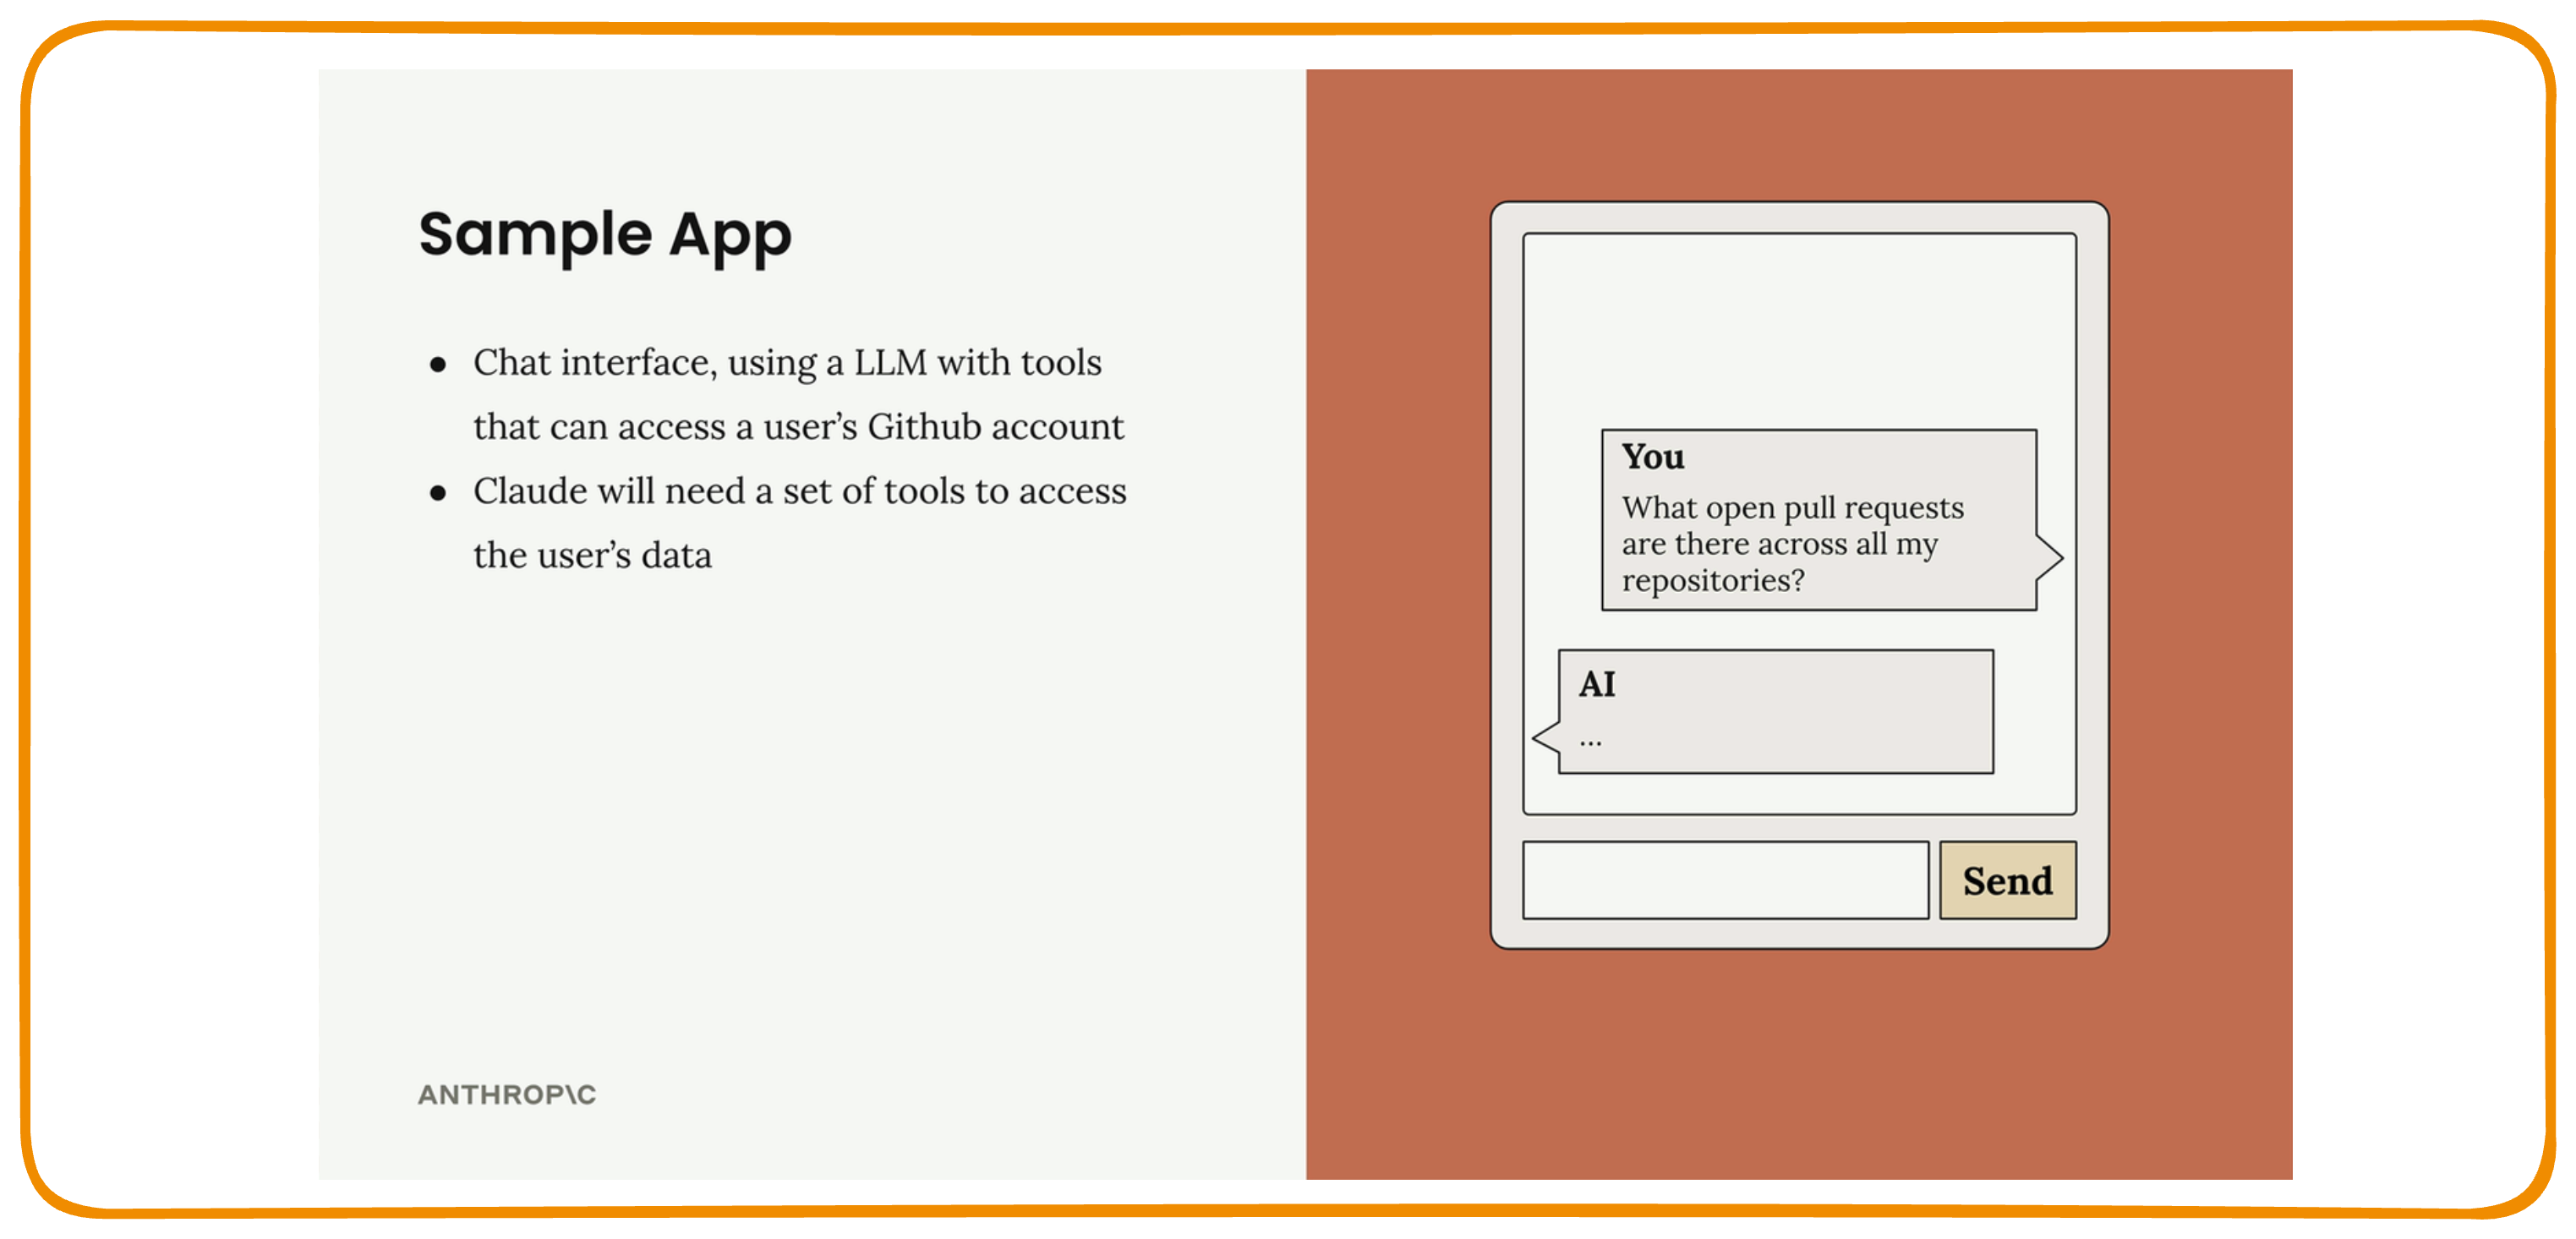

# The Problem MCP Solves: A GitHub Integration Example

## The Traditional Approach

Consider building an AI application that needs to interact with the GitHub API — creating issues, listing repositories, reviewing pull requests, searching code.

Without MCP, the developer must manually:

1. **Author a JSON tool schema** for every GitHub operation the model needs access to. Each schema defines the tool name, parameter types, descriptions, and expected outputs — all written by hand.
2. **Implement the execution function** for each tool. This is the actual code that receives the model's arguments, calls the GitHub API, handles authentication, parses the response, and returns structured results.
3. **Maintain both layers** as the GitHub API evolves. Schema changes, new endpoints, deprecated fields, and authentication updates all require manual developer intervention across every tool definition.

For a service as large as GitHub's API, this can mean dozens of tool schemas and dozens of corresponding functions — all custom-built, all individually maintained.

Now multiply this across every service the application integrates with: Slack, Google Drive, a database, a CI/CD pipeline. Each service demands the same per-tool authoring effort. This is the **M x N integration burden** at the tool-definition level.

## What MCP Changes

MCP relocates the responsibility for tool definition and execution from the application developer to a dedicated **MCP Server**.

For GitHub, this means someone (often GitHub themselves or the community) builds a GitHub MCP Server that:

- Wraps GitHub API operations as pre-built tools with complete schemas
- Handles authentication, request formatting, and response parsing internally
- Exposes these tools through the standardized MCP interface

The application developer's work reduces to one task: **connect an MCP Client to the GitHub MCP Server**. The Client queries the Server for available tools, surfaces them to the model, and relays execution requests back to the Server. The developer writes zero tool schemas and zero GitHub API integration code.

## The Core Shift

| Concern | Without MCP | With MCP |
|---|---|---|
| Tool schema authoring | Developer writes manually per tool | Server provides pre-built schemas |
| Tool execution logic | Developer implements per tool | Server handles execution internally |
| API maintenance burden | Falls on every application developer | Falls on the Server author once |
| Adding a new service | Repeat all work for each new API | Connect to that service's MCP Server |

MCP does not eliminate the work of building tool integrations. It **shifts who does the work** — from every application developer independently to a single MCP Server implementation that all clients can reuse.

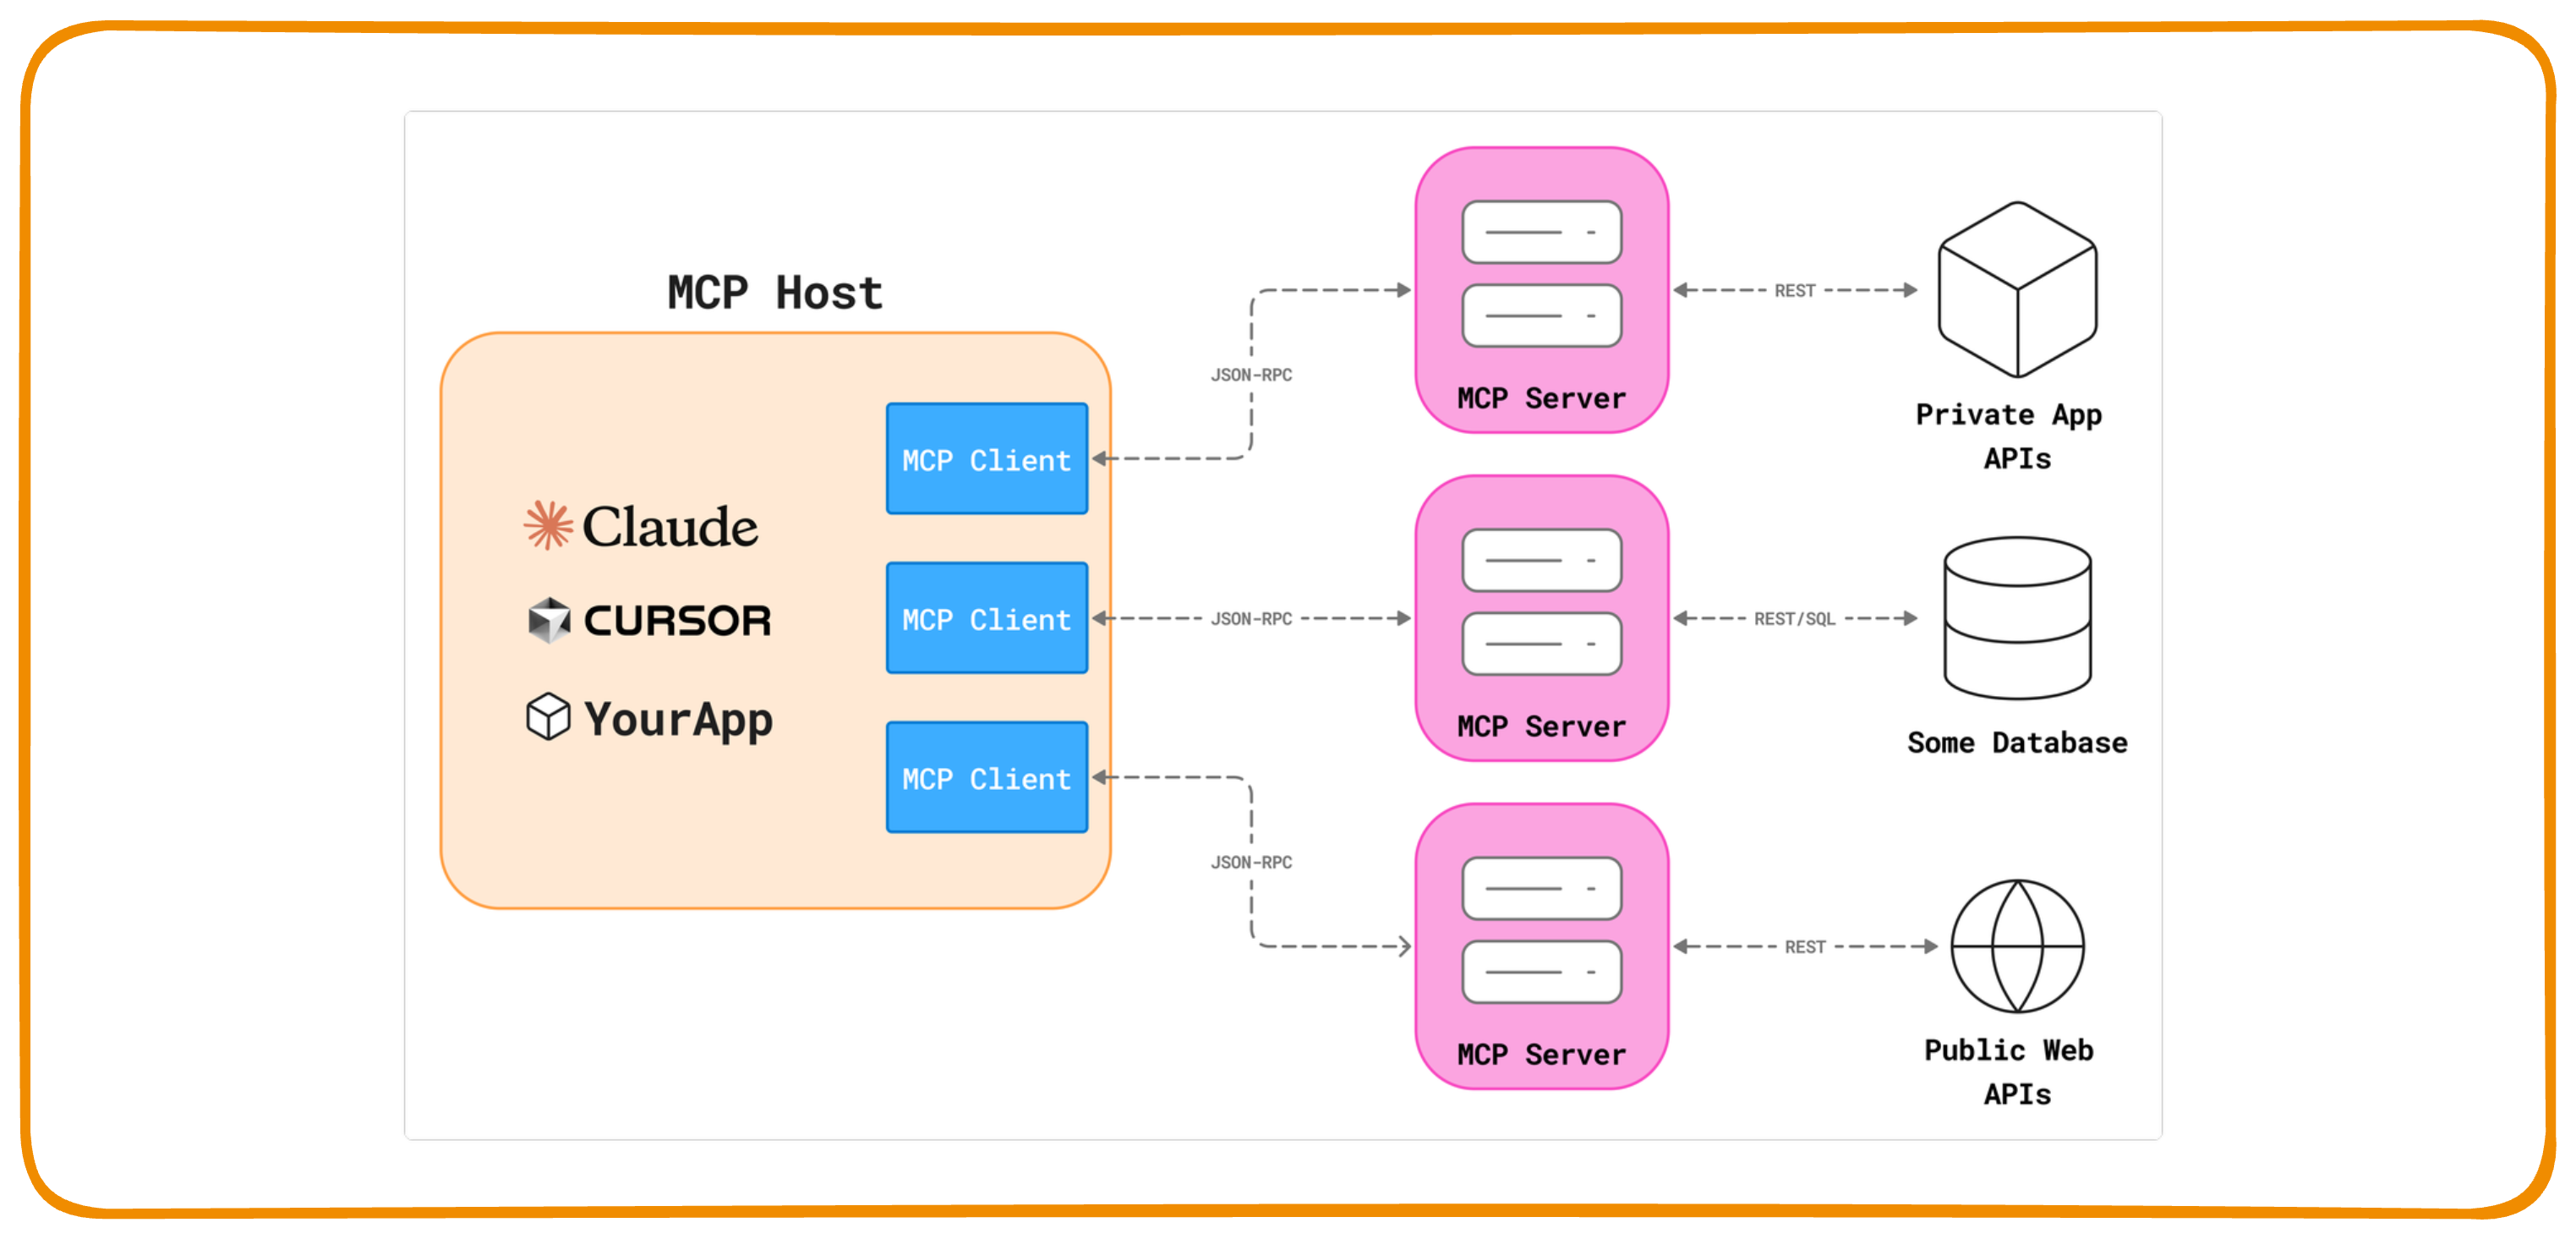

# MCP Architecture: Core Components

The Model Context Protocol defines a three-component architecture — Host, Client, and Server — that governs how AI applications discover and invoke external capabilities. The protocol builds on JSON-RPC 2.0 for structured message exchange, and enforces a strict separation of concerns across these components to maintain security boundaries, session isolation, and modular extensibility.

---

## MCP Host

The Host is the top-level, user-facing AI application — an IDE with embedded AI assistance, a conversational agent interface, or a custom orchestration platform. It serves as the **process-level container and coordinator** for the entire MCP session.

Core responsibilities:

- **Lifecycle management.** The Host instantiates, configures, and tears down one or more MCP Client instances. Each Client maps to a single Server connection, but the Host may manage many such connections concurrently.
- **LLM coordination.** The Host mediates between the language model and the connected Clients, routing the model's tool invocation requests to the appropriate Client and feeding results back into the model's context window.
- **Security boundary enforcement.** The Host is the trust boundary. It controls which Servers are connected, what capabilities are exposed to the model, and whether user consent is required before tool execution. No Server interacts with the LLM directly; all access is mediated through the Host.
- **Capability aggregation.** When multiple Servers are connected, the Host consolidates their advertised capabilities (tools, resources, prompts) into a unified interface available to the model.

Architecturally, the Host implements the **Mediated Access Pattern**: the LLM never directly reaches external systems. Every request and response passes through the Host's control plane.

---

## MCP Client

The Client is a **protocol-level adapter** embedded within the Host application. It handles the mechanics of MCP communication with a single Server.

Core responsibilities:

- **1:1 Server binding.** Each Client instance maintains a dedicated, stateful session with exactly one MCP Server. If the Host needs access to five Servers, it instantiates five Clients.
- **Protocol negotiation.** During connection initialization, the Client and its paired Server perform a capability handshake: each side declares the features it supports (tool invocation, resource access, sampling, subscription notifications). Both parties must respect these declared capabilities for the duration of the session.
- **Message transport.** The Client manages the underlying transport (stdio for local Servers, HTTP with SSE for remote Servers) and serializes all exchanges as JSON-RPC 2.0 messages — requests, responses, and notifications.
- **Capability discovery relay.** The Client queries its Server for available tools, resources, and prompts, then surfaces these to the Host for aggregation and presentation to the model.

The Client is not application logic. It is infrastructure: a protocol bridge that isolates the Host from transport-level and session-level concerns.

---

## MCP Server

The Server is a **standalone process or service** that exposes a defined set of capabilities to MCP Clients via the standardized protocol interface.

Core responsibilities:

- **Capability exposure.** Servers advertise their capabilities through MCP primitives — **tools** (executable functions), **resources** (data endpoints), and **prompts** (templated interaction patterns). Each capability is declared with structured metadata (name, description, input schema) that enables the model to introspect and invoke it.
- **Backend abstraction.** The Server translates incoming MCP requests into safe, scoped operations against its underlying system — a database query, a file read, an API call, a code execution step. The model and Client have no knowledge of backend internals.
- **Focused responsibility.** Each Server is designed around a single integration domain (e.g., a PostgreSQL Server, a GitHub Server, a filesystem Server). This follows the single-responsibility principle: Servers are lightweight, independently deployable, and composable.
- **Security scoping.** Servers authenticate incoming requests, enforce access controls, and constrain operations to their declared scope. They never receive direct access to the LLM or to other Servers.

---

## Component Interaction Model

In a typical MCP session, these components interact as follows: the Host receives a user query, passes it to the LLM along with the aggregated capability descriptions from all connected Servers, and the LLM determines which tool or resource to invoke. The Host then routes the invocation through the appropriate Client, which sends a JSON-RPC request to its paired Server. The Server executes the operation, returns a structured result via the Client, and the Host incorporates that result into the LLM's context for response generation.

This three-layer decomposition — Host as coordinator, Client as protocol bridge, Server as capability provider — ensures that adding new capabilities requires only deploying a new Server, with no modifications to the Host or existing Servers.

# MCP Servers: Overview

An MCP Server is a standalone process or service that exposes capabilities to AI applications through the Model Context Protocol. It acts as the **interface between an external system** (a database, an API, a filesystem) **and any MCP-compliant client**, packaging that system's functionality into a standardized, discoverable set of primitives.

The server is where the actual work happens. It defines tools, hosts resources, and provides prompts — the client never executes operations directly.

---

## The Three Server Primitives

MCP Servers expose capabilities through exactly three primitive types, differentiated by **who controls their invocation**.

| Primitive | Control | Purpose | Example |
|---|---|---|---|
| **Tools** | Model-controlled | Executable functions the LLM decides to invoke | API POST requests, file writing, code execution |
| **Resources** | Application-controlled | Structured data the app code decides to fetch | File contents, git history, document listings |
| **Prompts** | User-controlled | Pre-built templates the user triggers explicitly | Slash commands, menu options, chat starters |

---

### Tools — Serve the Model

Tools give the LLM the ability to **take actions and retrieve information**. The model inspects the available tool schemas and autonomously decides when to call them during a conversation.

- Defined with the `@mcp.tool` decorator and typed function signatures
- The Python SDK auto-generates JSON schemas from the function definition — no manual schema authoring
- Parameters use Pydantic `Field()` for descriptions and validation
- The Server executes the tool logic (e.g., calling an external API) and returns the result

Example: a `read_doc_contents` tool that takes a `doc_id` parameter, looks up the document, and returns its content. The model decides when this tool is needed based on the user's query.

### Resources — Serve the Application

Resources expose **read-only data endpoints** that application code fetches proactively — for UI rendering, prompt augmentation, or context injection. The model does not invoke resources; the application does.

- Defined with the `@mcp.resource` decorator and a URI pattern
- Two types: **static** URIs (`docs://documents`) and **templated** URIs (`documents/{doc_id}`)
- Each resource declares a MIME type (`application/json`, `text/plain`) so the client knows how to deserialize the response
- URI parameters in templates map directly to function keyword arguments

Example: a resource at `docs://documents` returns a JSON list of all available documents, which the app uses to populate a selection menu before the conversation begins.

### Prompts — Serve the User

Prompts are **pre-authored, tested instruction templates** that users trigger through explicit actions like slash commands or button clicks. They encapsulate domain-specific prompt engineering within the Server rather than leaving it to end users.

- Defined with the `@mcp.prompt` decorator with a name and description
- Accept parameterized arguments (e.g., a document ID) that get interpolated into the template
- Return a structured message sequence (user/assistant format) sent directly to the model
- Clients surface them as slash commands (e.g., `/format`)

Example: a `/format` prompt that takes a document ID, generates an instruction to rewrite the document in markdown, and returns the full message sequence for the model to execute.

---

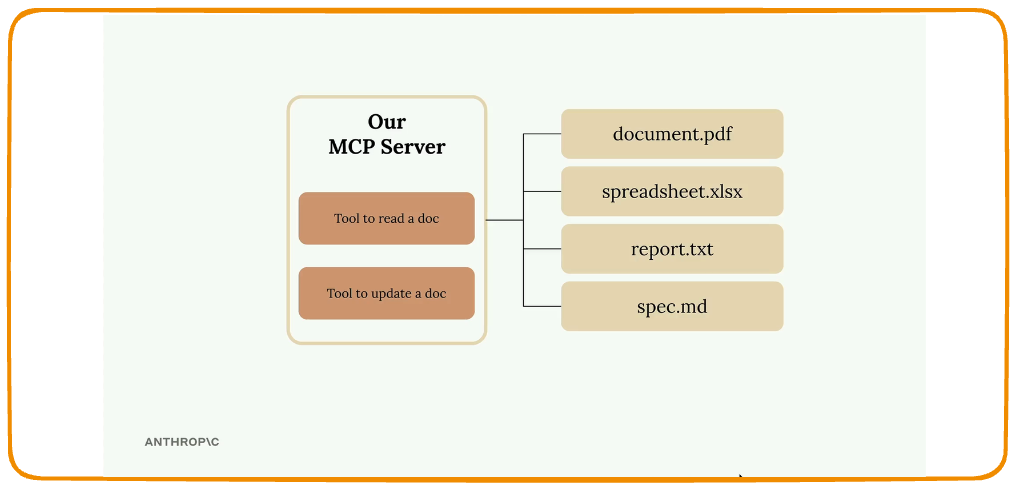

# MCP Server: Code Flow Example

This walkthrough traces the implementation flow of an MCP Server that manages an in-memory document system, exposing two tools, two resources, and one prompt.

---

## Server Initialization

The Python MCP SDK reduces server creation to a single line. All primitives (tools, resources, prompts) are registered via decorators on the same server instance.

```python
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("Document Server")
```

The backing data store is a simple in-memory dictionary:

```python
docs = {
    "report.pdf": "Quarterly revenue increased 15% year-over-year...",
    "notes.txt": "Meeting notes from sprint planning session..."
}
```

---

## Tool Definitions

### Tool 1: Read Document

**Flow:** Decorator → typed parameters with `Field()` descriptions → validation → return content.

```python
from pydantic import Field

@mcp.tool()
def read_doc_contents(doc_id: str = Field(description="ID of the document to read")) -> str:
    if doc_id not in docs:
        raise ValueError(f"Document {doc_id} not found")
    return docs[doc_id]
```

The SDK auto-generates the JSON tool schema from this function signature. No manual schema authoring.

### Tool 2: Edit Document

**Flow:** Decorator → three typed parameters → existence validation → find/replace operation → confirmation.

```python
@mcp.tool()
def edit_document(
    doc_id: str = Field(description="ID of the document to edit"),
    old_string: str = Field(description="Text to find"),
    new_string: str = Field(description="Replacement text")
) -> str:
    if doc_id not in docs:
        raise ValueError(f"Document {doc_id} not found")
    docs[doc_id] = docs[doc_id].replace(old_string, new_string)
    return "Document updated successfully"
```



# Understanding MCP clients

MCP clients are instantiated by host applications to communicate with particular MCP servers. The host application, like Claude.ai or an IDE, manages the overall user experience and coordinates multiple clients. Each client handles one direct communication with one server.

Understanding the distinction is important: the *host* is the application users interact with, while *clients* are the protocol-level components that enable server connections.

## Core Client Features

In addition to making use of context provided by servers, clients may provide several features to servers. These client features allow server authors to build richer interactions.

| Feature         | Explanation                                                                                                                                                                                       | Example                                                                                                                                |
| --------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| **Elicitation** | Elicitation enables servers to request specific information from users during interactions, providing a structured way for servers to gather information on demand.                               | A server booking travel may ask for the user's preferences on airplane seats, room type or their contact number to finalise a booking. |
| **Roots**       | Roots allow clients to specify which directories servers should focus on, communicating intended scope through a coordination mechanism.                                                          | A server for booking travel may be given access to a specific directory, from which it can read a user's calendar.                     |
| **Sampling**    | Sampling allows servers to request LLM completions through the client, enabling an agentic workflow. This approach puts the client in complete control of user permissions and security measures. | A server for booking travel may send a list of flights to an LLM and request that the LLM pick the best flight for the user.           |

### Elicitation

Elicitation enables servers to request specific information from users during interactions, creating more dynamic and responsive workflows.

#### Overview

Elicitation provides a structured way for servers to gather necessary information on demand. Instead of requiring all information up front or failing when data is missing, servers can pause their operations to request specific inputs from users. This creates more flexible interactions where servers adapt to user needs rather than following rigid patterns.

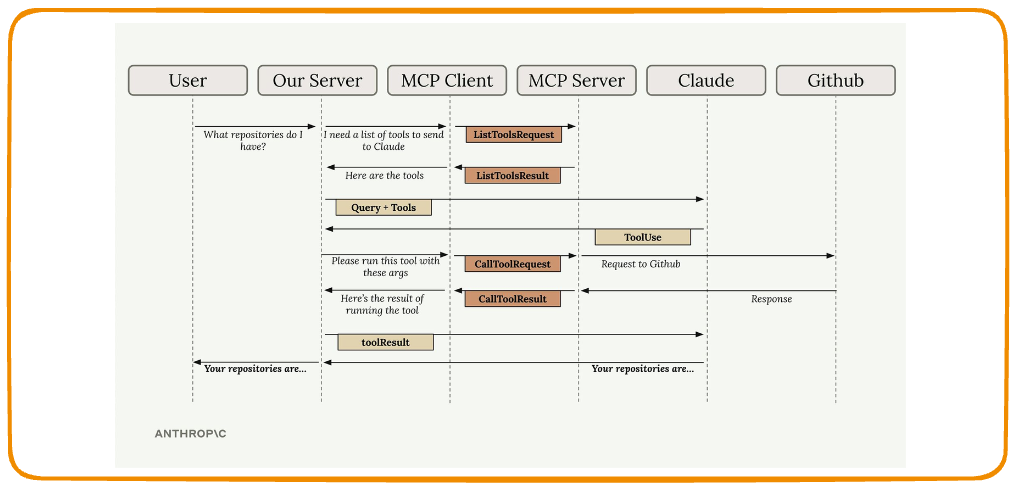

# MCP Client: Code Flow Example

This walkthrough traces the implementation flow of an MCP Client that connects to a Server, discovers its capabilities, and exposes them to the rest of the application.

---

## Client Initialization

The Client wraps the MCP SDK's `ClientSession` in a class that manages connection lifecycle and resource cleanup.

```python
from mcp import ClientSession

class MCPClient:
    def __init__(self):
        self.session = None

    async def __aenter__(self):
        await self.connect()
        return self

    async def __aexit__(self, *args):
        await self.cleanup()
```

**Flow:** Instantiate → `connect()` establishes session with the Server → `cleanup()` tears it down on exit.

The `ClientSession` is the actual connection to the MCP Server. Wrapping it in a class with async context management ensures proper resource cleanup when the Client shuts down.

---

## Tool Discovery

**Flow:** Application needs tools for the LLM → Client queries Server → returns tool list.

```python
async def list_tools(self):
    result = await self.session.list_tools()
    return result.tools
```

This sends a `tools/list` JSON-RPC request to the Server. The Server responds with its available tools and their schemas. The Client passes them through — it does not interpret or modify the schemas.

---

## Tool Execution

**Flow:** LLM selects a tool and provides arguments → Client forwards to Server → Server executes → Client returns result.

```python
async def call_tool(self, tool_name: str, tool_input: dict):
    result = await self.session.call_tool(tool_name, tool_input)
    return result
```

This sends a `tools/call` JSON-RPC request. The Client never executes the tool itself — it relays the invocation to the Server, which performs the actual operation (API call, database query, file read) and returns the result.

---

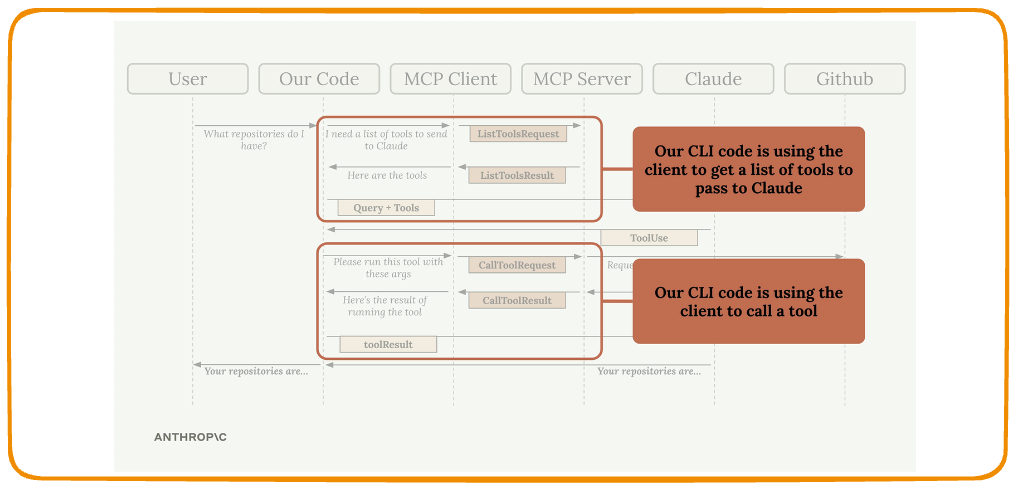

# Additional Server Features: Resources

Resources are the second primitive an MCP Server can expose. Unlike tools (which are model-controlled and execute operations), resources are **application-controlled** and provide **read-only data access**. The application code — not the LLM — decides when to fetch a resource.

---

## Purpose

Resources exist to get data into the application layer for purposes outside the model's direct control: populating a document selector in the UI, injecting context into a prompt before the LLM sees it, providing autocomplete options, or displaying metadata. The model does not invoke resources; the Host application does.

Real-world example: a Google Drive MCP Server exposes a resource that lists available documents. The application fetches this resource to render a file picker — no LLM involvement required.

---

## URI-Based Addressing

Every resource is identified by a URI, following the same pattern as web routes. MCP supports two URI types:

### Static Resources

Fixed URI, returns the same structural endpoint every time.

```python
@mcp.resource("docs://documents", mime_type="application/json")
def list_documents() -> list[str]:
    return list(docs.keys())
```

The URI `docs://documents` always maps to this function. The application calls `read_resource("docs://documents")` and receives a JSON list of document IDs.

### Templated Resources

Parameterized URI with placeholders that map to function keyword arguments.

```python
@mcp.resource("documents/{doc_id}", mime_type="text/plain")
def get_document(doc_id: str) -> str:
    if doc_id not in docs:
        raise ValueError(f"Document {doc_id} not found")
    return docs[doc_id]
```

The URI `documents/report.pdf` extracts `doc_id="report.pdf"` and passes it to the function. One resource definition serves any document by ID.

---

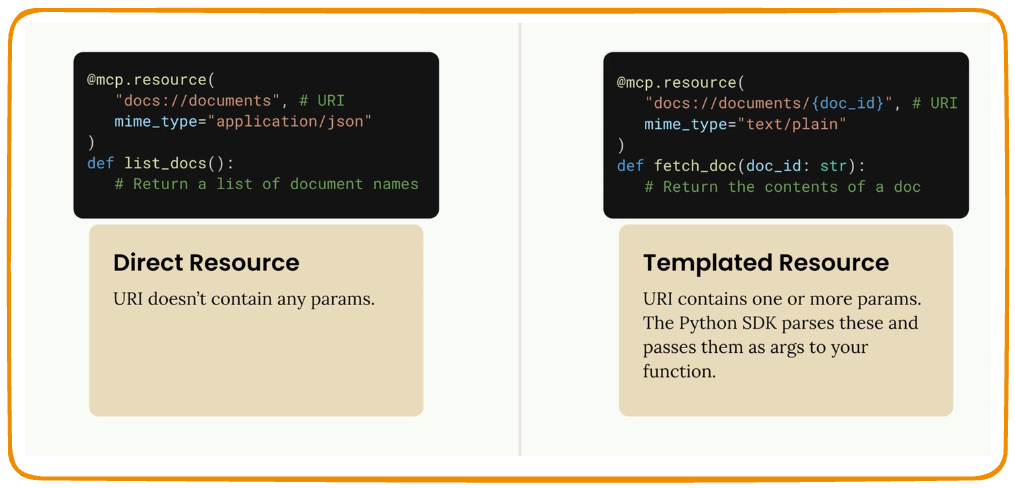

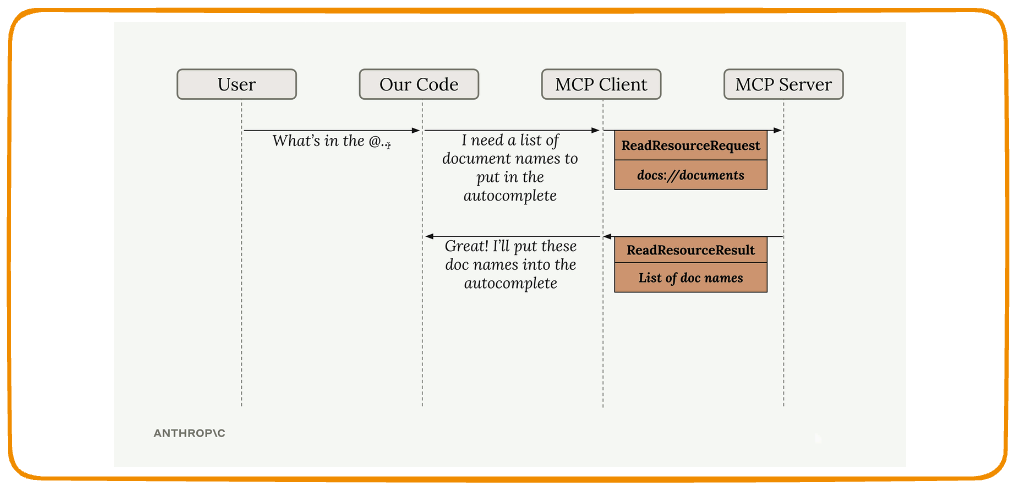

## MIME Types

Each resource declares a MIME type that tells the Client how to deserialize the response:

| MIME Type | Use Case | Client Handling |
|---|---|---|
| `application/json` | Structured data (lists, objects) | `json.loads(resource.text)` |
| `text/plain` | Raw text content | Return `resource.text` directly |

The Python SDK auto-serializes return values to strings. The MIME type is a hint — it does not enforce format, but Clients rely on it for correct parsing.

---

## Design Pattern

One resource per distinct read operation. Listing all items and fetching a single item are separate resources with separate URIs:

- `docs://documents` → returns list of all document IDs
- `documents/{doc_id}` → returns content of a specific document

This mirrors RESTful API design: collection endpoint vs. individual item endpoint.

---

## Resources vs. Tools

| | Resources | Tools |
|---|---|---|
| **Controlled by** | Application code | LLM |
| **Operation type** | Read-only data access | Executable actions |
| **When invoked** | Proactively by the app (before or outside of LLM interaction) | Reactively by the model (during inference) |
| **Use case** | UI population, context injection, prompt augmentation | API calls, file writes, computations |

A resource fetches data that the application needs. A tool performs an action that the model decides is necessary. If the LLM needs to read a document during a conversation, that is a tool. If the application needs a document list to show a picker before the conversation starts, that is a resource.

# Additional Server Features: Resources (Client Side)

The previous section covered how the Server defines resources. This section covers how the Client accesses them — fetching data, parsing responses, and integrating resource content into the application.

---

## Client Interface

The Client exposes a single function for reading resources:

```python
import json
from pydantic import AnyUrl

async def read_resource(self, uri: str):
    result = await self.session.read_resource(AnyUrl(uri))
    resource = result.contents[0]

    if resource.mime_type == "application/json":
        return json.loads(resource.text)
    return resource.text
```

---

## Code Flow Breakdown

### 1. URI Submission

The application passes a URI string. The Client wraps it in `AnyUrl` (from Pydantic) for type compliance and sends a `read_resource` request to the Server.

### 2. Response Extraction

The Server returns a result containing a `contents` list. The Client accesses `contents[0]` — the first (and typically only) resource in the response.

### 3. MIME-Based Parsing

The Client checks `resource.mime_type` to determine how to deserialize:

| MIME Type | Client Action |
|---|---|
| `application/json` | `json.loads(resource.text)` → returns Python dict/list |
| Anything else | Returns `resource.text` as a raw string |

This is the Client's only interpretation step. Everything else is pass-through.

---

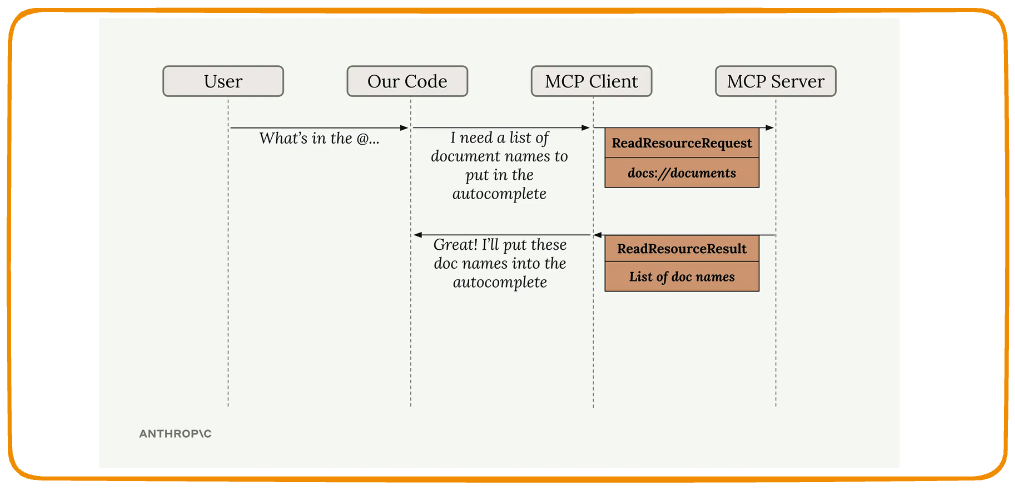

# Additional Server Features: Prompts (Server Side)

Prompts are the third primitive an MCP Server can expose. They are **user-controlled**: triggered by explicit user actions (slash commands, button clicks, menu selections), not by the LLM or application code. The Server authors pre-written, tested instruction templates that encapsulate domain-specific prompt engineering, so end users don't have to craft prompts themselves.

---

## Purpose

The core idea: the Server author — who understands the domain, the tools, and what instructions produce the best model behavior — writes the prompt once. Every Client that connects to this Server gets access to that optimized prompt without any user effort.

Real-world example: Claude's chat starter buttons are prompts. A user clicks one, and a pre-authored instruction sequence is sent to the model.

---

## Server Implementation

### Defining a Prompt

**Flow:** Decorator with name and description → function receives arguments → returns a message list.

```python
@mcp.prompt(name="format", description="Rewrites a document in markdown format")
def format_document(doc_id: str) -> list:
    return [
        {
            "role": "user",
            "content": f"Read the document '{doc_id}' using the read_doc_contents tool, "
                       f"rewrite its contents in clean markdown format, "
                       f"then save the result using the edit_document tool."
        }
    ]
```

### What Happens Inside

1. The `@mcp.prompt` decorator registers the function with a name (`"format"`) and description
2. When a Client calls `get_prompt("format", {"doc_id": "report.pdf"})`, the Server maps `doc_id` to the function's keyword argument
3. The function interpolates `doc_id` into the template text
4. The Server returns a **messages array** — a structured conversation sequence ready for the LLM

The Server does not send this to the model itself. It returns the messages to the Client, which forwards them to the Host, which sends them to the LLM.

---

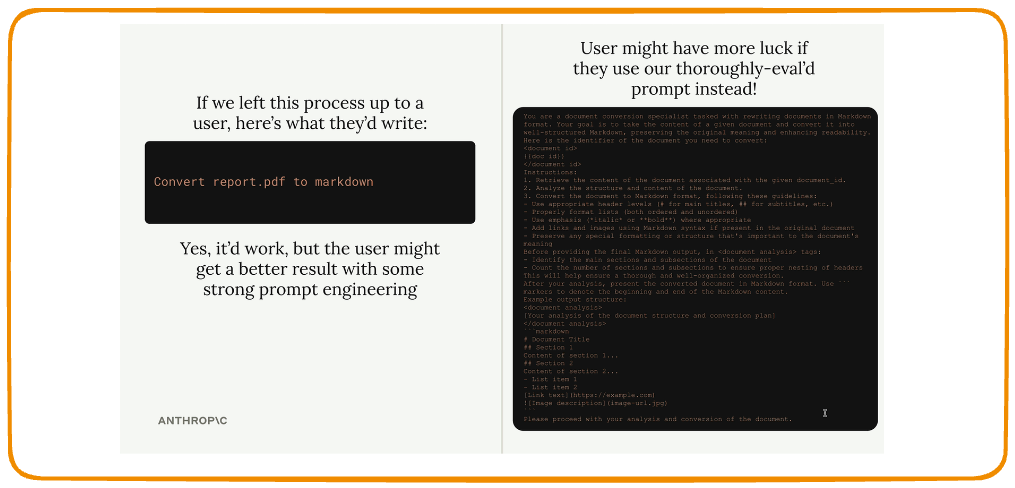

# Additional Server Features: Prompts (Client Side)

The previous section covered how the Server defines prompts. This section covers how the Client discovers, retrieves, and delivers them — acting as the transport between a user-triggered action and the LLM.

---

## Client Interface

The Client exposes two functions for working with prompts:

### Discovering Available Prompts

```python
async def list_prompts(self):
    result = await self.session.list_prompts()
    return result.prompts
```

Sends a `list_prompts` request to the Server. Returns metadata (name, description, expected arguments) for every prompt the Server offers. The application uses this to render available options to the user — slash commands in a CLI, buttons in a UI.

### Retrieving a Specific Prompt

```python
async def get_prompt(self, prompt_name: str, arguments: dict):
    result = await self.session.get_prompt(prompt_name, arguments)
    return result.messages
```

Sends a `get_prompt` request with the prompt name and a dictionary of arguments. The Server interpolates the arguments into its template and returns a **messages array** — a ready-to-send conversation sequence for the LLM.

---

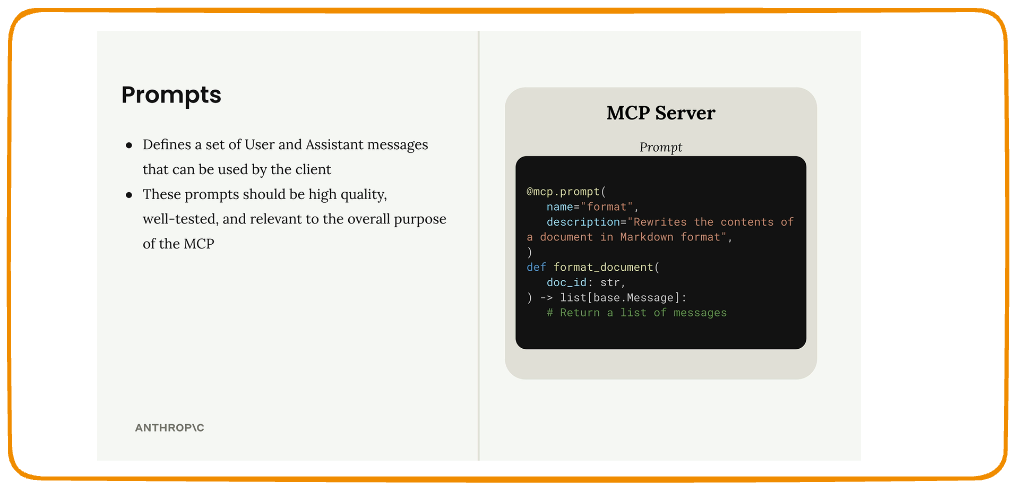

#Transports and Communication

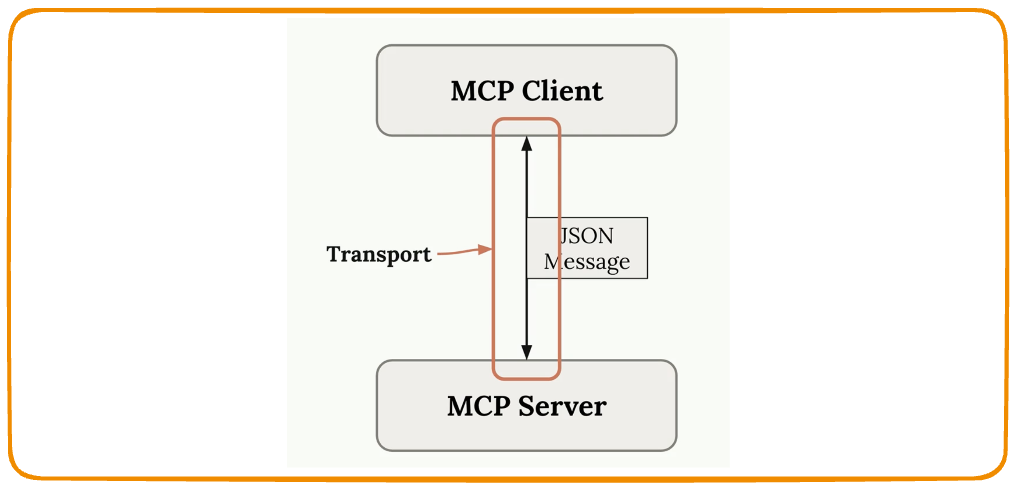

# Transports and Communication: JSON Message Types

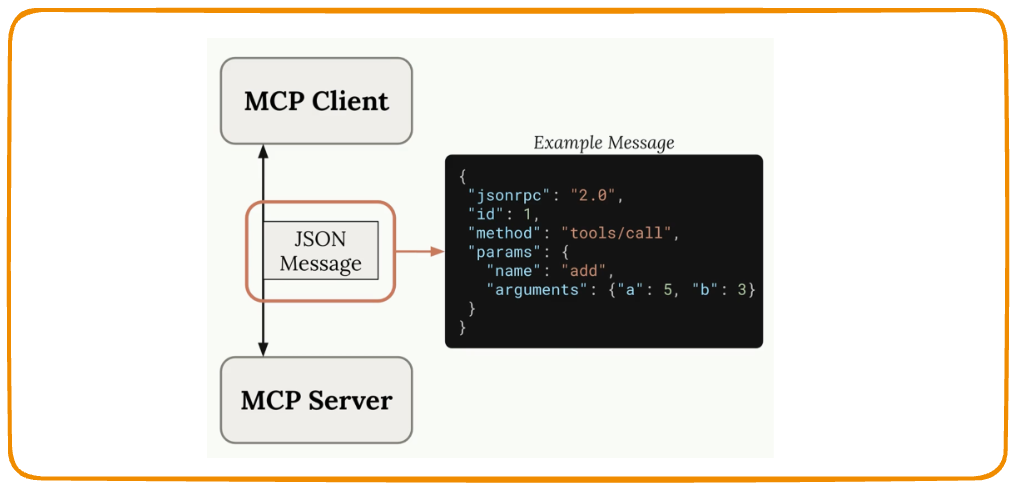



All MCP communication between Clients and Servers is expressed as **JSON messages** using the JSON-RPC format. Understanding the message taxonomy is essential before examining the transport layers that carry them.

---

## Message Categories

MCP messages fall into three types, distinguished by whether they expect a response:

### Requests

A message that **expects a result** in return. Always part of a request/result pair.

```
Client → Server:  call_tool_request    → expects call_tool_result
Client → Server:  initialize_request   → expects initialize_result
Client → Server:  list_tools_request   → expects list_tools_result
```

### Results

The **response to a request**. Completes the request/result pair.

```
Server → Client:  call_tool_result
Server → Client:  initialize_result
Server → Client:  list_tools_result
```

### Notifications

**Fire-and-forget** messages that do not expect a response. Used for events and status updates.

```
Server → Client:  progress_notification
Server → Client:  logging_message_notification
Server → Client:  tool_change_notification
Client → Server:  initialized_notification
```

---

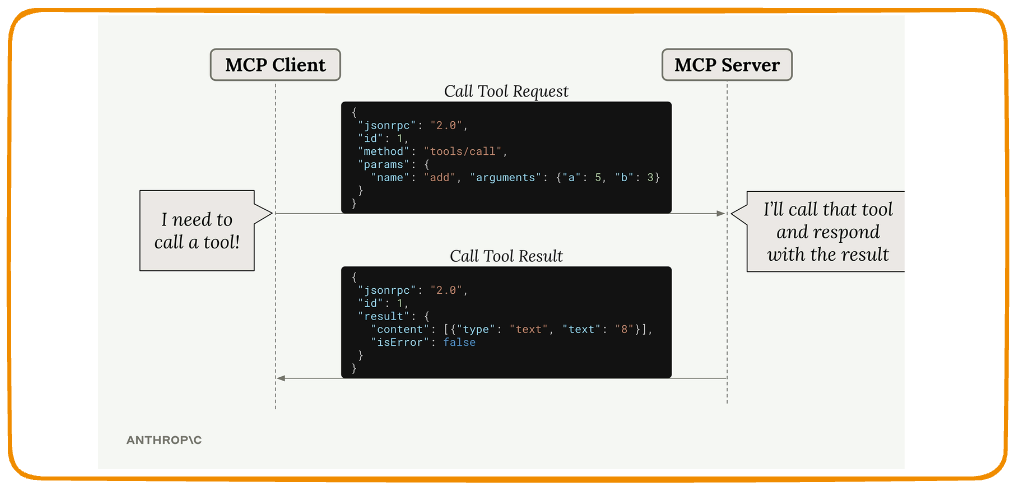

# Transports and Communication: The Stdio Transport

The transport layer is the mechanism that carries JSON-RPC messages between Client and Server. The **stdio transport** is the simplest option: the Client launches the Server as a child process on the same machine and communicates through standard input/output streams.

---

## How It Works

The Client spawns the Server as a separate process. Once running, the two communicate through the Server's stdin and stdout:

- **Client → Server:** Client writes JSON messages to the Server's stdin
- **Server → Client:** Server writes JSON messages to its stdout, which the Client reads

No network, no HTTP, no ports. Just two processes on the same machine exchanging text through OS-level I/O streams.

---

## Initialization Sequence

Before any tool calls or resource reads can happen, the Client and Server must complete a three-step handshake:

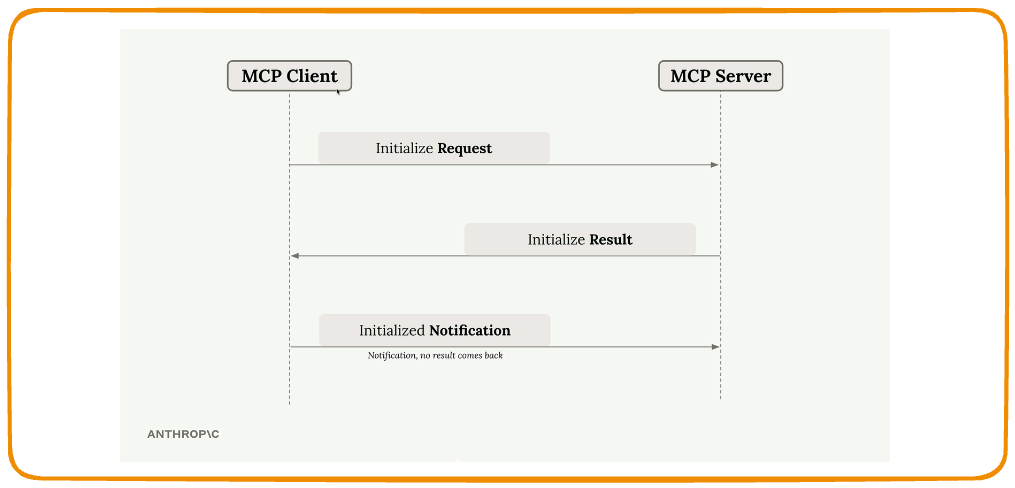




After step 3, the session is established and the Client can begin sending `list_tools`, `call_tool`, `read_resource`, and `get_prompt` requests.

---

## Bidirectional Communication

The key characteristic of stdio is **full bidirectional messaging**. Either side can initiate communication at any time:

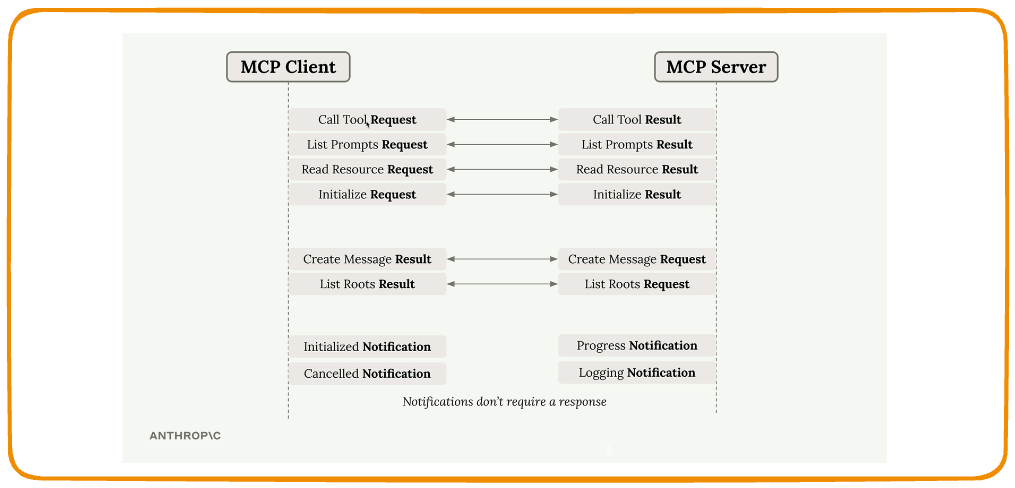

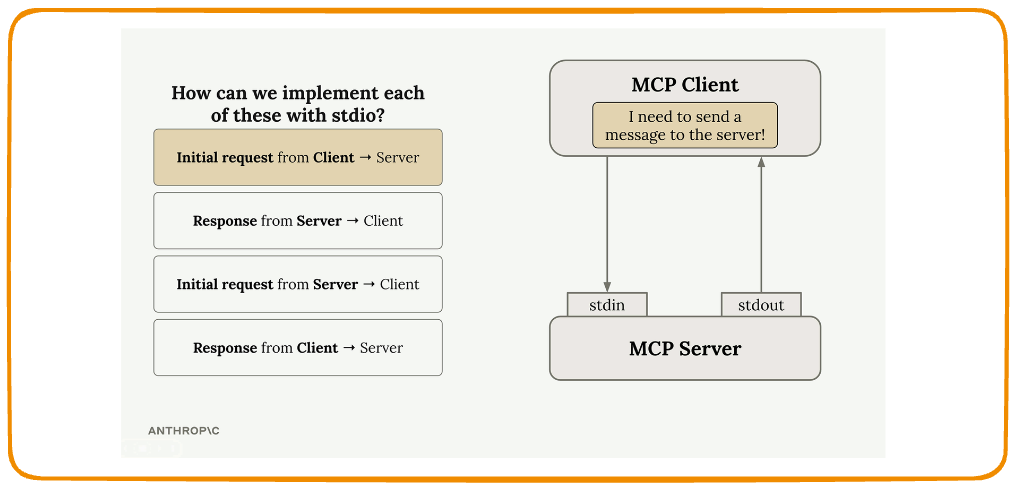




This means the Server can:
- Push **progress notifications** during long-running tool execution
- Send **logging messages** for real-time debugging feedback
- Initiate **sampling requests** asking the Client to generate LLM completions

All Server-to-Client message types work without restriction under stdio. There are no workarounds needed — the communication channel is inherently symmetric.

---

## Limitation

Stdio requires the Client and Server to run on the **same physical machine**. The Server is a child process of the Client; there is no network layer between them.

This makes stdio ideal for local development and same-machine deployments, but unusable for remote Server hosting (e.g., a publicly accessible MCP Server at a URL).

---

# Transports and Communication: The Streamable HTTP Transport

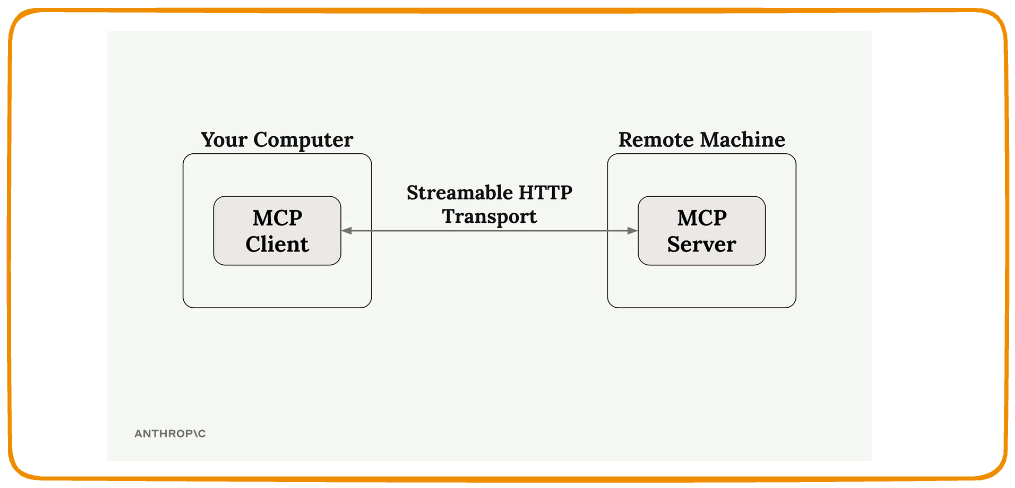

The Streamable HTTP transport enables **remote Server hosting** — Servers accessible over the network at a URL, not confined to the same machine as the Client. This unlocks publicly accessible MCP Servers, but introduces a fundamental constraint.

---

## The Core Problem

HTTP is inherently **client-to-server**. Clients make requests; servers respond. But MCP requires the reverse too — Servers need to push progress notifications, logging messages, and sampling requests *to* the Client. HTTP has no native mechanism for this.

---

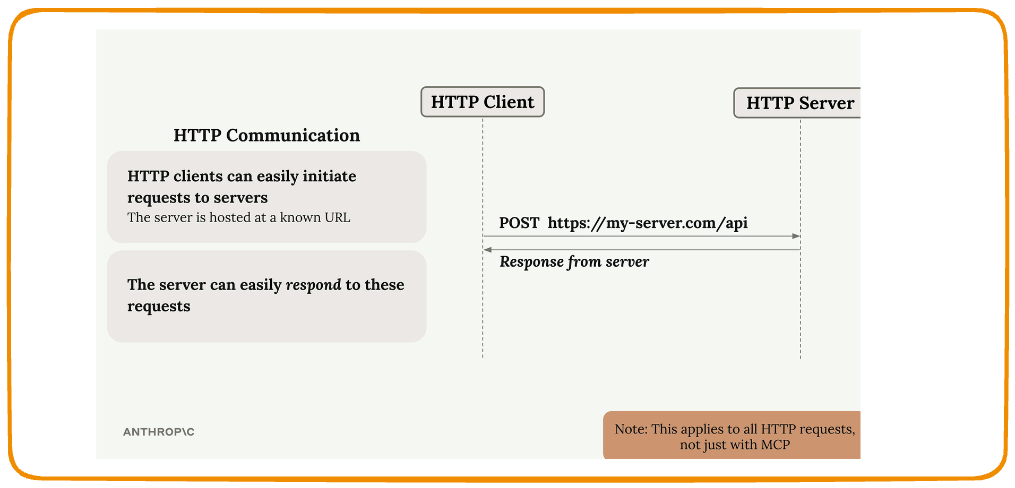



## The SSE Workaround

Streamable HTTP solves this using **Server-Sent Events (SSE)** — persistent connections that allow the Server to stream messages to the Client.

### Session Setup

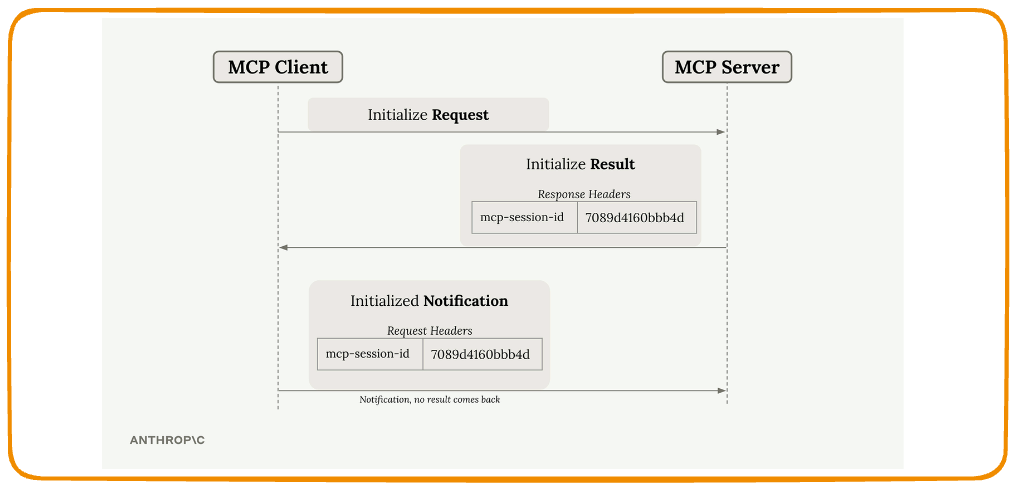

### Two SSE Channels

| Connection | Lifetime | Carries |
|---|---|---|
| **Long-lived SSE** (GET) | Persists for entire session | Server-initiated requests: sampling, general notifications |
| **Short-lived SSE** (POST response) | Closes after tool result | Tool results, logging messages, progress for that specific call |

---

## Configuration Flags

Two flags significantly alter behavior:

### `stateless_http` (default: false)

Set to `true` for **horizontal scaling** with load balancers. Disables session IDs, disables the GET SSE connection, and eliminates all Server-to-Client initiated messages (sampling, progress, logging). The trade-off: scalability at the cost of features.

### `json_response` (default: false)

Set to `true` to disable **streaming on POST responses**. The Client receives only the final result as plain JSON — no intermediate progress or log messages during execution.

---

## What Breaks and When

| Feature | stdio | HTTP (defaults) | HTTP (stateless=true) | HTTP (json_response=true) |
|---|---|---|---|---|
| Progress notifications | Works | Works | Broken | Broken |
| Logging messages | Works | Works | Broken | Broken |
| Sampling requests | Works | Works | Broken | Broken |
| Tool execution | Works | Works | Works | Works |

---

## The Deployment Pitfall

An application built and tested with stdio locally will have full bidirectional messaging. Deploying that same application with Streamable HTTP — especially with either flag set to `true` — silently disables features that worked during development. Always develop against the same transport you plan to deploy with.

# Core MCP Features

# Core MCP Features: Sampling

Sampling allows an MCP Server to **request LLM text generation from the Client** instead of calling an LLM directly. The Server asks; the Client generates; the result flows back.

---

## The Problem Sampling Solves

Some MCP Servers need LLM capabilities as part of their tool logic — summarizing retrieved data, classifying inputs, generating responses. Without sampling, the Server would need to:

- Hold its own API keys for an LLM provider
- Handle authentication and token billing
- Manage rate limits and error handling for LLM calls

For publicly accessible Servers, this is a security and cost liability. Anyone connecting to the Server could trigger LLM calls on the Server's account.

---

## How Sampling Works

Sampling inverts the responsibility. The Server delegates LLM access to the Client, which already has an authenticated connection to a model.

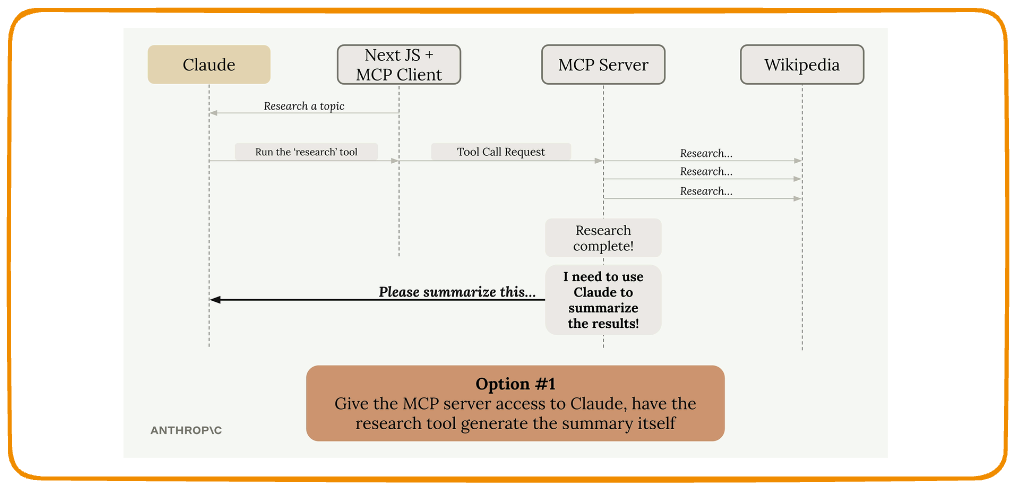

**Option 1: Give the MCP server direct access to Claude. The server would need its own API key, handle authentication, manage costs, and implement all the Claude integration code. This works but adds significant complexity.**

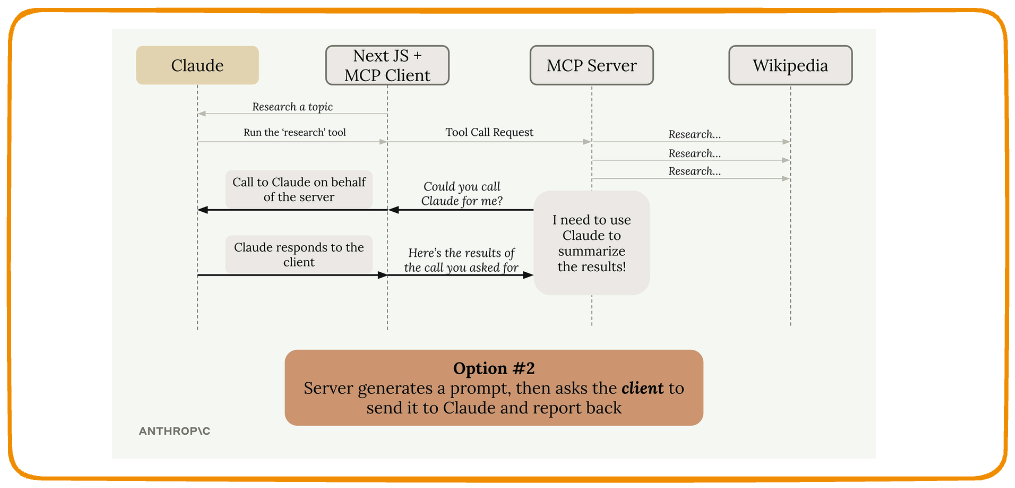

**Option 2: Use sampling. The server generates a prompt and asks the client "Could you call Claude for me?" The client, which already has a connection to Claude, makes the call and returns the results.**

# Core MCP Features: Sampling — Implementation

## Server Side

The Server requests LLM generation using `create_message()` with a list of messages:

```python
result = await context.create_message(
    messages=[
        {"role": "user", "content": "Summarize the following data: ..."}
    ]
)
# result contains the LLM-generated text
```

No API keys, no model configuration. The Server just sends messages and receives generated text back.

## Client Side

The Client implements a **sampling callback** that handles incoming generation requests from the Server:

```python
async def sampling_callback(request):
    # Client receives the Server's message list
    # Client calls its own LLM (already authenticated)
    response = await call_llm(request.messages)

    # Client returns the generated text to the Server
    return create_message_result(response)
```

The callback is registered with the Client session. When the Server calls `create_message()`, the Client's callback fires, generates the completion, and returns the result through the same MCP channel.

# Core MCP Features: Log and Progress Notifications

Log and progress notifications provide **real-time feedback** during tool execution. Without them, long-running operations appear stalled to the user — no indication of whether the tool is working, stuck, or failed.

This is an optional feature, purely for UX enhancement.

---

## Server Side

Tool functions automatically receive a `context` object as their last parameter. This object exposes two methods:

```python
@mcp.tool()
async def process_large_file(
    file_id: str = Field(description="File to process"),
    context=None
):
    await context.info("Starting file processing...")

    for i in range(10):
        # Do work...
        await context.report_progress(i + 1, 10)
        await context.info(f"Processing chunk {i + 1} of 10")

    return "Processing complete"
```

- **`context.info(message)`** — sends a logging notification to the Client
- **`context.report_progress(current, total)`** — sends a progress notification to the Client

Calling either method automatically pushes a message back through the MCP channel. No extra wiring needed on the Server side.

---

## Client Side

The Client registers **callback functions** to handle incoming notifications:

```python
# Define callbacks
async def log_callback(message):
    print(f"[LOG] {message}")

async def progress_callback(current, total):
    print(f"[PROGRESS] {current}/{total}")

# Pass log callback when creating the client session
session = ClientSession(log_callback=log_callback)

# Pass progress callback when calling a tool
result = await client.call_tool(
    "process_large_file",
    {"file_id": "data.csv"},
    progress_callback=progress_callback
)
```

- **Log callback** → registered on the Client session (receives all logging messages)
- **Progress callback** → passed per `call_tool` invocation (scoped to that specific execution)

The callbacks determine *how* to display feedback — terminal output, progress bar in a web UI, status indicator in an IDE. The protocol delivers the data; the Client decides the presentation.

---

## Transport Dependency

Both logging and progress are **Server-to-Client notifications** — the Server pushes messages without expecting a response. This means:

| Transport | Logging | Progress |
|---|---|---|
| **Stdio** | Works | Works |
| **Streamable HTTP (defaults)** | Works (via SSE) | Works (via SSE) |
| **Streamable HTTP (stateless=true)** | Broken | Broken |
| **Streamable HTTP (json_response=true)** | Broken | Broken |

If either HTTP flag is set to `true`, the Server has no channel to push intermediate messages. The Client receives only the final tool result.

# Core MCP Features: Roots

Roots are a **Client-declared mechanism** for granting an MCP Server access to specific files and directories. They define the filesystem boundary within which the Server is allowed to operate.

---

## The Problem Without Roots

A user asks: *"Convert bikin.mp4 to gif."*

The Server has a `ConvertVideo` tool, but it needs the full file path to operate. The user doesn't know (or want to type) `/home/user/projects/vacation-2024/media/raw/bikin.mp4`. Without a way to scope and discover files, every request requires an exact path — impractical for real usage.

---

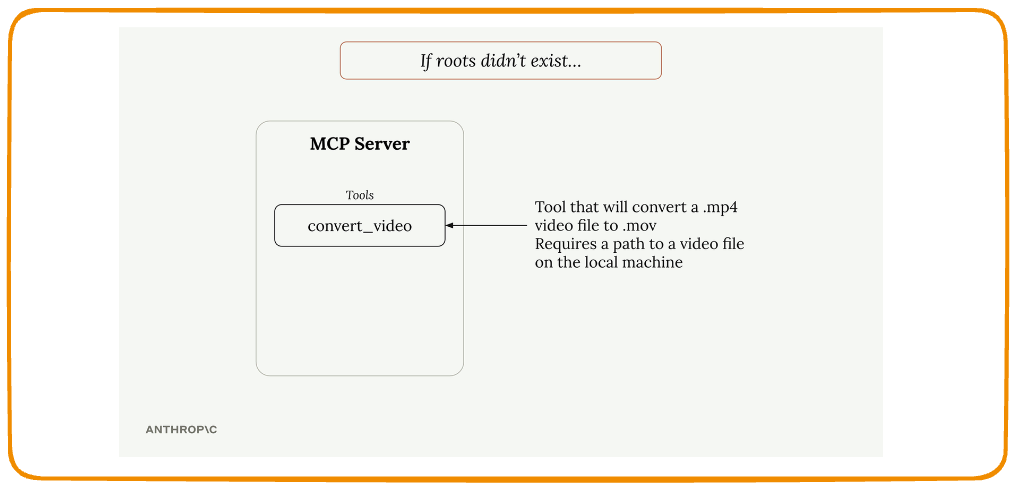

## How Roots Work

Roots are files or directories the user **grants permission to beforehand**, typically as command-line arguments when starting the Server:

```bash
mcp start server.py --roots /home/user/videos /home/user/documents
```

The Server now knows it has access to two directory trees. With supporting tools, the LLM can autonomously navigate these roots to find the file the user is referring to.

---

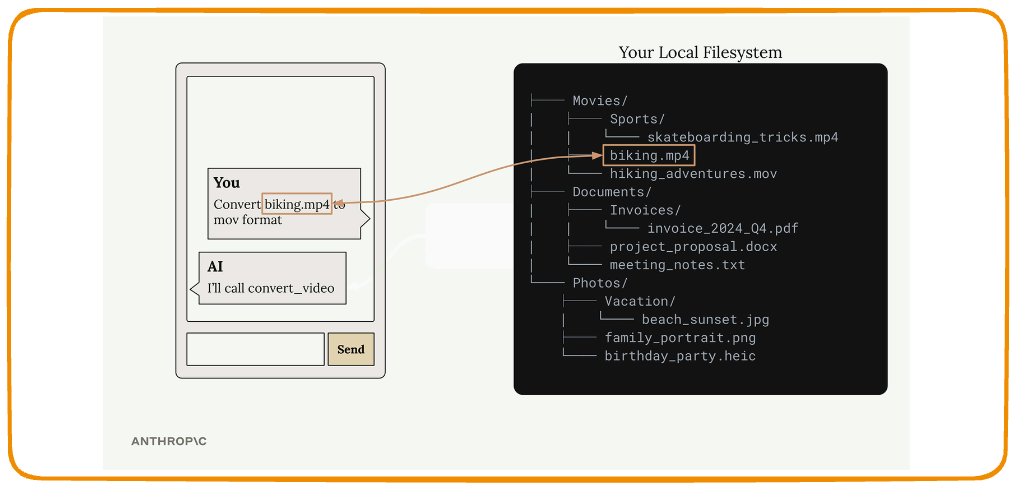

The Server now knows it has access to two directory trees. With supporting tools, the LLM can autonomously navigate these roots to find the file the user is referring to.

---

## Implementation Pattern

Roots require **three tools** working together:

### 1. ListRoots — discover available access points

```python
@mcp.tool()
def list_roots() -> list[str]:
    return granted_roots  # ["/home/user/videos", "/home/user/documents"]
```

### 2. ReadDirectory — navigate within a root

```python
@mcp.tool()
def read_directory(path: str = Field(description="Directory path to list")) -> list[str]:
    if not is_path_allowed(path):
        raise ValueError("Access denied: path is outside granted roots")
    return os.listdir(path)
```

### 3. The domain tool — operates on discovered files

```python
@mcp.tool()
def convert_video(file_path: str = Field(description="Path to video file")) -> str:
    if not is_path_allowed(file_path):
        raise ValueError("Access denied: path is outside granted roots")
    # conversion logic...
    return "Conversion complete"
```

---

## Access Control: Manual Enforcement

The MCP SDK **does not automatically enforce** root restrictions. Every tool that touches the filesystem must manually check that the requested path falls within a granted root:

```python
def is_path_allowed(requested_path: str) -> bool:
    for root in granted_roots:
        if os.path.commonpath([root, requested_path]) == root:
            return True
    return False
```

This is a critical implementation detail. Without `is_path_allowed()` checks, a Server that advertises roots as its boundary can still be instructed to access files outside them.

---